 # Importing libraries

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor,
    BaggingRegressor
)
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from xgboost import XGBRegressor
from catboost import CatBoostRegressor

from sklearn.base import clone

from copy import deepcopy

In [2]:
pd.set_option('display.max_rows', 5000)
pd.set_option('display.max_columns', 5000)

In [3]:
train = pd.read_csv(r"C:\Users\ismai\Downloads\archive (24)\ALLtrainMescla5D.csv")
test = pd.read_csv(r"C:\Users\ismai\Downloads\archive (24)\ALLtestMescla5D.csv")


Preprocessing

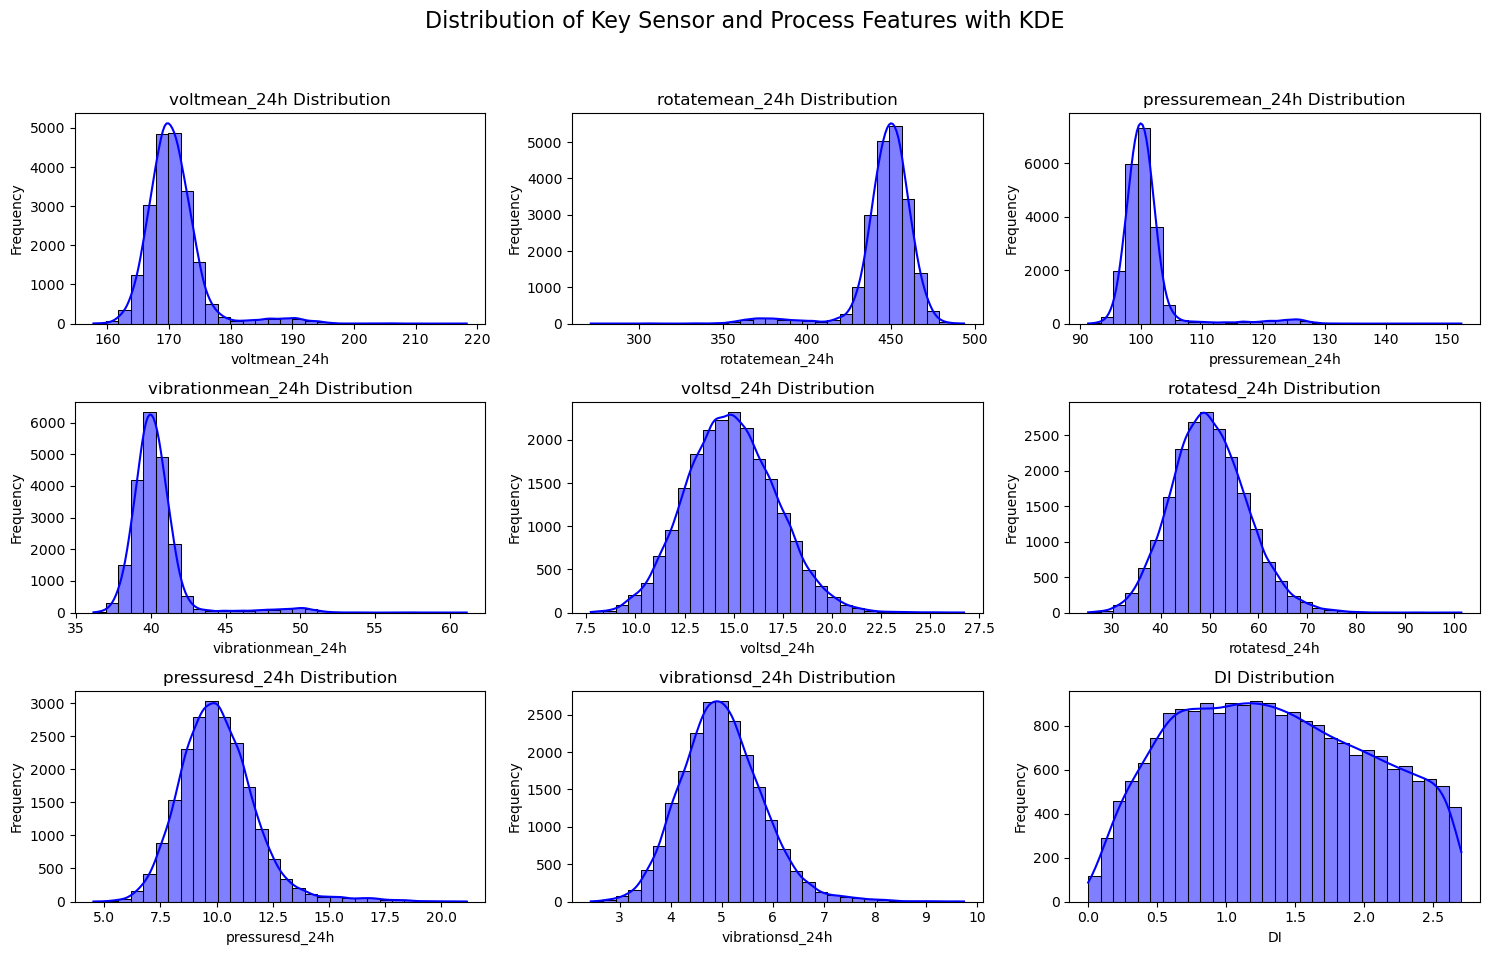

In [6]:
features_to_plot = ['voltmean_24h', 'rotatemean_24h',
       'pressuremean_24h', 'vibrationmean_24h', 'voltsd_24h', 'rotatesd_24h',
       'pressuresd_24h', 'vibrationsd_24h','DI']
plt.figure(figsize=(15, 10))  # Set overall figure size

for i, feature in enumerate(features_to_plot):
    plt.subplot(3, 3, i + 1)  # Create a 3x3 grid of subplots
    sns.histplot(train[feature], kde=True, bins=30, color='blue')  # Plot histogram with KDE curve
    plt.title(f"{feature} Distribution")  # Set subplot title
    plt.xlabel(feature)  # Label x-axis
    plt.ylabel("Frequency")  # Label y-axis

# Set a shared super-title for the entire figure
plt.suptitle("Distribution of Key Sensor and Process Features with KDE", fontsize=16)
 # Adjust layout to accommodate the suptitle
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.savefig("feature_distributions.pdf", dpi=300, bbox_inches="tight")

plt.show()

C:\Users\ismai\AppData\Local\Temp\ipykernel_23288\2053380426.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x='failed', y=feature, palette='coolwarm')  # Plot boxplot by failure class
C:\Users\ismai\AppData\Local\Temp\ipykernel_23288\2053380426.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x='failed', y=feature, palette='coolwarm')  # Plot boxplot by failure class
C:\Users\ismai\AppData\Local\Temp\ipykernel_23288\2053380426.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x='failed', y=featur

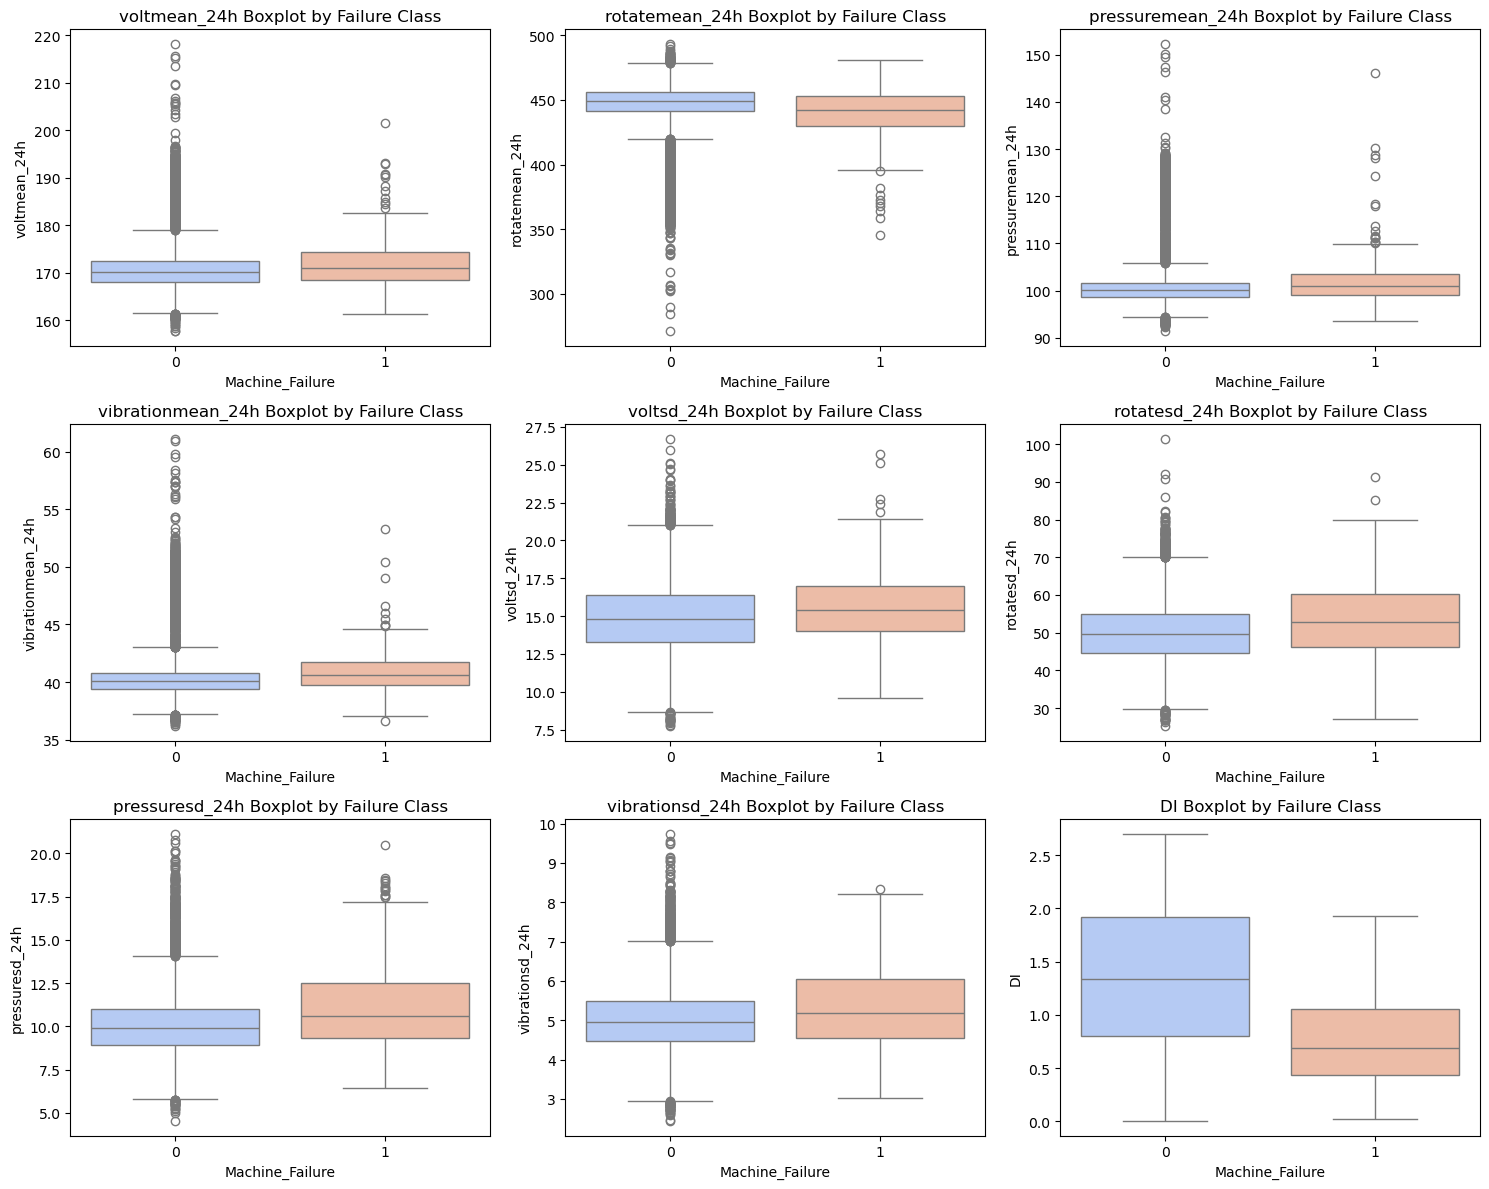

In [7]:
plt.figure(figsize=(15, 12))  # Set overall figure size

for i, feature in enumerate(features_to_plot):
    plt.subplot(3, 3, i + 1)  # Create a 3x3 grid of subplots
    sns.boxplot(data=train, x='failed', y=feature, palette='coolwarm')  # Plot boxplot by failure class
    plt.title(f"{feature} Boxplot by Failure Class")  # Set plot title
    plt.xlabel("Machine_Failure")  # Label x-axis
    plt.ylabel(feature)  # Label y-axis

plt.tight_layout()
plt.savefig("feature_boxplots.pdf", dpi=300, bbox_inches="tight")# Adjust layout to prevent overlap
plt.show()

1)"Factory specific model for 24 hours of sensor data"

In [22]:
train_24_x = train[['machineID', 'time_in_cycles', 'voltmean_24h',
       'rotatemean_24h', 'pressuremean_24h', 'vibrationmean_24h', 'voltsd_24h',
       'rotatesd_24h', 'pressuresd_24h', 'vibrationsd_24h', 'error1', 'error2',
       'error3', 'error4', 'error5', 'comp1', 'comp2', 'comp3', 'comp4', 'age', 'DI']]

train_5_x = train[['machineID', 'time_in_cycles', 'voltmean_5d',
       'rotatemean_5d', 'pressuremean_5d', 'vibrationmean_5d', 'voltsd_5d',
       'rotatesd_5d', 'pressuresd_5d', 'vibrationsd_5d', 'error1', 'error2',
       'error3', 'error4', 'error5', 'comp1', 'comp2', 'comp3', 'comp4',
       'age', 'DI']]

train_y = train['RUL']



test_24_x = test[['machineID', 'time_in_cycles', 'voltmean_24h',
       'rotatemean_24h', 'pressuremean_24h', 'vibrationmean_24h', 'voltsd_24h',
       'rotatesd_24h', 'pressuresd_24h', 'vibrationsd_24h', 'error1', 'error2',
       'error3', 'error4', 'error5', 'comp1', 'comp2', 'comp3', 'comp4', 'age', 'DI']]

test_5_x = test[['machineID', 'time_in_cycles',  'voltmean_5d',
       'rotatemean_5d', 'pressuremean_5d', 'vibrationmean_5d', 'voltsd_5d',
       'rotatesd_5d', 'pressuresd_5d', 'vibrationsd_5d', 'error1', 'error2',
       'error3', 'error4', 'error5', 'comp1', 'comp2', 'comp3', 'comp4',
       'age', 'DI']]


test_y = test['RUL']

In [23]:

cat_features = ['machineID']  
# OR indices: cat_features = [0]  (if machineID is first column)

model_specific_24h = CatBoostRegressor(
    iterations=500,
    depth=6,
    learning_rate=0.1,
    loss_function='RMSE'
)

model_specific_5d = CatBoostRegressor(
    iterations=500,
    depth=6,
    learning_rate=0.1,
    loss_function='RMSE'
)

model_specific_24h.fit(
    train_24_x,
    train_y,
    cat_features=cat_features,
    verbose=False
)

model_specific_5d.fit(
    train_5_x,
    train_y,
    cat_features=cat_features,
    verbose=False
)



y_pred_24h = model_specific_24h.predict(test_24_x)
y_pred_5d = model_specific_5d.predict(test_5_x)

In [24]:

y_true = test_y.values

# ---------- 24H Metrics ----------
mae_24 = mean_absolute_error(y_true, y_pred_24h)
mse_24 = mean_squared_error(y_true, y_pred_24h)
rmse_24 = np.sqrt(mse_24)
r2_24 = r2_score(y_true, y_pred_24h)

mape_24 = np.mean(np.abs((y_true - y_pred_24h) / y_true)) * 100


# ---------- 5D Metrics ----------
mae_5 = mean_absolute_error(y_true, y_pred_5d)
mse_5 = mean_squared_error(y_true, y_pred_5d)
rmse_5 = np.sqrt(mse_5)
r2_5 = r2_score(y_true, y_pred_5d)

mape_5 = np.mean(np.abs((y_true - y_pred_5d) / y_true)) * 100


# ---------- Create Comparison Table ----------
results_df = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R2 Score", "MAPE (%)"],
    "24H Model": [mae_24, mse_24, rmse_24, r2_24, mape_24],
    "5D Model": [mae_5, mse_5, rmse_5, r2_5, mape_5]
})

print("\n===== CatBoost Model Comparison =====\n")
print(results_df)


===== CatBoost Model Comparison =====

     Metric   24H Model    5D Model
0       MAE    4.854038    5.045265
1       MSE  143.708714  149.808968
2      RMSE   11.987857   12.239647
3  R2 Score    0.913579    0.909911
4  MAPE (%)   12.020512   12.289095


In [25]:
test['catboost_24h_predictions'] = y_pred_24h
test['catboost_5d_predictions'] = y_pred_5d

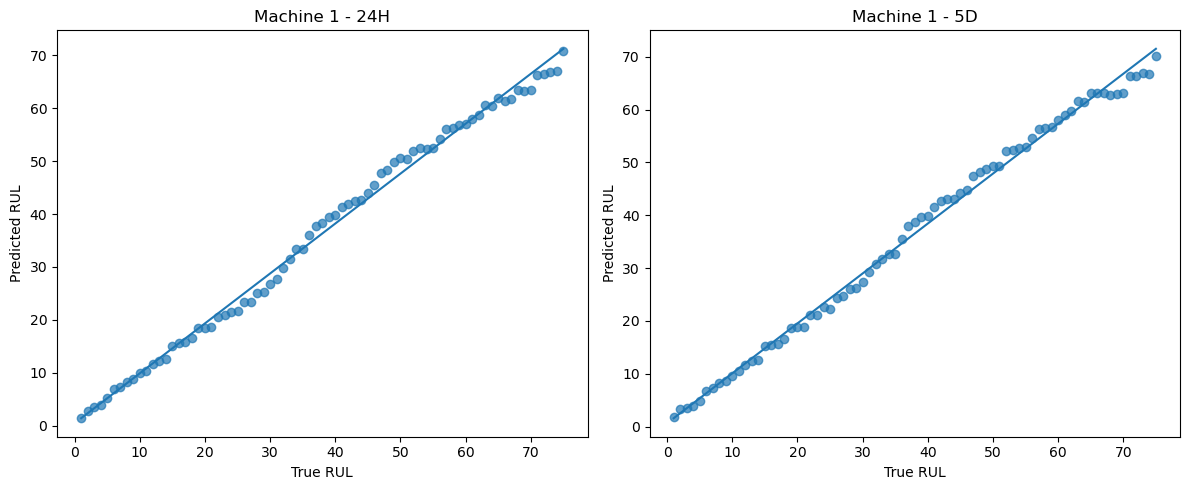

In [13]:

# Select machine
machine_id = 1
df_m1 = test[test['machineID'] == machine_id]

y_true = df_m1['RUL'].values
y_pred_24 = df_m1['catboost_24h_predictions'].values
y_pred_5  = df_m1['catboost_5d_predictions'].values

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# ------------------ 24H ------------------
coef_24 = np.polyfit(y_true, y_pred_24, 1)
line_x = np.linspace(y_true.min(), y_true.max(), 100)
line_y_24 = coef_24[0] * line_x + coef_24[1]

axes[0].scatter(y_true, y_pred_24, alpha=0.7)
axes[0].plot(line_x, line_y_24)
axes[0].set_xlabel("True RUL")
axes[0].set_ylabel("Predicted RUL")
axes[0].set_title(f"Machine {machine_id} - 24H")

# ------------------ 5D ------------------
coef_5 = np.polyfit(y_true, y_pred_5, 1)
line_y_5 = coef_5[0] * line_x + coef_5[1]

axes[1].scatter(y_true, y_pred_5, alpha=0.7)
axes[1].plot(line_x, line_y_5)
axes[1].set_xlabel("True RUL")
axes[1].set_ylabel("Predicted RUL")
axes[1].set_title(f"Machine {machine_id} - 5D")

plt.tight_layout()
plt.savefig("Machine_known_scatter_plots.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [14]:
model_specific_24h.get_feature_importance(prettified=True)

,Feature Id,Importances
0,machineID,42.060118
1,DI,38.750240
2,age,13.623406
3,time_in_cycles,5.227875
4,comp4,0.192437
5,comp2,0.076998
6,rotatemean_24h,0.009134
7,voltmean_24h,0.009021
8,voltsd_24h,0.008865
9,comp3,0.008518


In [15]:
model_specific_5d.get_feature_importance(prettified=True)

,Feature Id,Importances
0,machineID,41.965287
1,DI,38.413126
2,age,14.140136
3,time_in_cycles,5.092190
4,comp4,0.203008
5,rotatesd_5d,0.027185
6,comp2,0.026512
7,vibrationsd_5d,0.025118
8,pressuremean_5d,0.022229
9,voltsd_5d,0.018250


In [16]:
per_machine_metrics = []

for mid in test['machineID'].unique():
    
    mask = test['machineID'] == mid
    
    y_true_m = test.loc[mask, 'RUL']
    y_pred_24_m = test.loc[mask, 'catboost_24h_predictions']
    y_pred_5_m  = test.loc[mask, 'catboost_5d_predictions']
    
    if len(y_true_m) > 5:
        
        per_machine_metrics.append({
            "MachineID": mid,
            
            "R2_24H": r2_score(y_true_m, y_pred_24_m),
            "MAE_24H": mean_absolute_error(y_true_m, y_pred_24_m),
            
            "R2_5D": r2_score(y_true_m, y_pred_5_m),
            "MAE_5D": mean_absolute_error(y_true_m, y_pred_5_m),
            
            "Samples": len(y_true_m)
        })

machine_known_specific_metrics_df = pd.DataFrame(per_machine_metrics)

print(machine_known_specific_metrics_df.head())

   MachineID    R2_24H   MAE_24H     R2_5D    MAE_5D  Samples
0          1  0.985729  1.890787  0.988098  1.679508       75
1          2  0.831907  3.192725  0.877368  2.540129       30
2          3  0.995458  1.170082  0.995198  1.192770       75
3          4  0.960129  3.982935  0.920101  5.654178      105
4          5  0.968744  1.950895  0.967311  1.998104       90


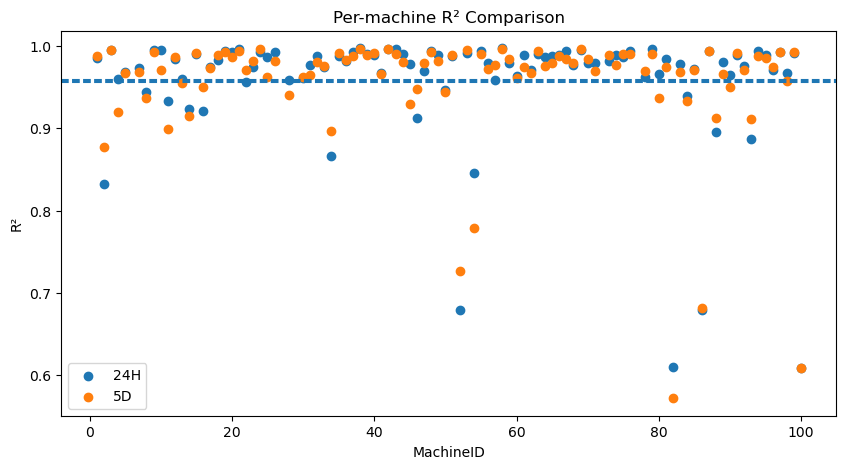

In [18]:
plt.figure(figsize=(10,5))

plt.scatter(machine_known_specific_metrics_df['MachineID'], machine_known_specific_metrics_df['R2_24H'], label='24H')
plt.scatter(machine_known_specific_metrics_df['MachineID'], machine_known_specific_metrics_df['R2_5D'], label='5D')

plt.axhline(machine_known_specific_metrics_df['R2_24H'].mean(), linestyle='--')
plt.axhline(machine_known_specific_metrics_df['R2_5D'].mean(), linestyle='--')

plt.xlabel("MachineID")
plt.ylabel("R²")
plt.title("Per-machine R² Comparison")
plt.legend()
plt.savefig("machine_known_per_machine_r2_scores.pdf", dpi=300, bbox_inches="tight")
plt.show()

Model function for generalized modelling

In [6]:
def models_all(model, x_train, y_train, x_test, y_test):

    model.fit(x_train, y_train)

    predictions = model.predict(x_test)

    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)

    metrics = {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }

    return metrics, predictions

In [7]:
models_dict = {
    "RandomForest": RandomForestRegressor(
        n_estimators=200,
        random_state=34,
        n_jobs=-1
    ),

    "DecisionTree": DecisionTreeRegressor(
        random_state=34
    ),

    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=34,
        n_jobs=-1
    ),

    "CatBoost": CatBoostRegressor(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        loss_function="RMSE",
        verbose=False,
        random_seed=34
    ),

    "MLP": MLPRegressor(
        solver='adam',
        max_iter=1000,
        learning_rate='adaptive',
        hidden_layer_sizes=(100,),
        alpha=0.01,
        activation='relu',
        random_state=34
    )
}


Generalized model for 24 hours of sensor data

In [20]:
train_24_general = train[['time_in_cycles', 'voltmean_24h',
       'rotatemean_24h', 'pressuremean_24h', 'vibrationmean_24h', 'voltsd_24h',
       'rotatesd_24h', 'pressuresd_24h', 'vibrationsd_24h', 'error1', 'error2',
       'error3', 'error4', 'error5', 'comp1', 'comp2', 'comp3', 'comp4', 'age', 'DI']]

train_5_general = train[['time_in_cycles', 'voltmean_5d',
       'rotatemean_5d', 'pressuremean_5d', 'vibrationmean_5d', 'voltsd_5d',
       'rotatesd_5d', 'pressuresd_5d', 'vibrationsd_5d', 'error1', 'error2',
       'error3', 'error4', 'error5', 'comp1', 'comp2', 'comp3', 'comp4',
       'age', 'DI']]

train_general = train['RUL']

test_24_general = test[['time_in_cycles', 'voltmean_24h',
       'rotatemean_24h', 'pressuremean_24h', 'vibrationmean_24h', 'voltsd_24h',
       'rotatesd_24h', 'pressuresd_24h', 'vibrationsd_24h', 'error1', 'error2',
       'error3', 'error4', 'error5', 'comp1', 'comp2', 'comp3', 'comp4', 'age', 'DI']]

test_5_general = test[['time_in_cycles',  'voltmean_5d',
       'rotatemean_5d', 'pressuremean_5d', 'vibrationmean_5d', 'voltsd_5d',
       'rotatesd_5d', 'pressuresd_5d', 'vibrationsd_5d', 'error1', 'error2',
       'error3', 'error4', 'error5', 'comp1', 'comp2', 'comp3', 'comp4',
       'age', 'DI']]

test_general = test['RUL']

In [21]:
results_general_24h = {}
predictions_general_24h = {}
trained_models_24h = {}
for name, model in models_dict.items():
    fresh_model = clone(model)
    metrics, preds = models_all(
        fresh_model,
        train_24_general,
        train_general,
        test_24_general,
        test_general
    )

    results_general_24h[name] = metrics
    predictions_general_24h[name] = preds
    trained_models_24h[name] = fresh_model

results_general_24h_df = pd.DataFrame(results_general_24h).T


results_general_5d = {}
predictions_general_5d = {}
trained_models_5d = {}
for name, model in models_dict.items():
    fresh_model = clone(model)
    metrics, preds = models_all(
        fresh_model,
        train_5_general,
        train_general,
        test_5_general,
        test_general
    )

    results_general_5d[name] = metrics
    predictions_general_5d[name] = preds
    trained_models_5d[name] = fresh_model

results_general_5d_df = pd.DataFrame(results_general_5d).T

In [23]:
test['RandomForest_predictions_24h'] = predictions_general_24h['RandomForest']
test['DecisionTree_predictions_24h'] = predictions_general_24h['DecisionTree']
test['XGBoost_predictions_24h'] = predictions_general_24h['XGBoost']
test['CatBoost_predictions_24h'] = predictions_general_24h['CatBoost']
test['MLP_predictions_24h'] = predictions_general_24h['MLP']

In [24]:
test['RandomForest_predictions_5d'] = predictions_general_5d['RandomForest']
test['DecisionTree_predictions_5d'] = predictions_general_5d['DecisionTree']
test['XGBoost_predictions_5d'] = predictions_general_5d['XGBoost']
test['CatBoost_predictions_5d'] = predictions_general_5d['CatBoost']
test['MLP_predictions_5d'] = predictions_general_5d['MLP']

In [25]:
machine_id = 24
df_plot = test[test['machineID'] == machine_id]

y_true = df_plot['RUL'].values

model_names = [
    "RandomForest",
    "DecisionTree",
    "XGBoost",
    "CatBoost",
    "MLP"
]


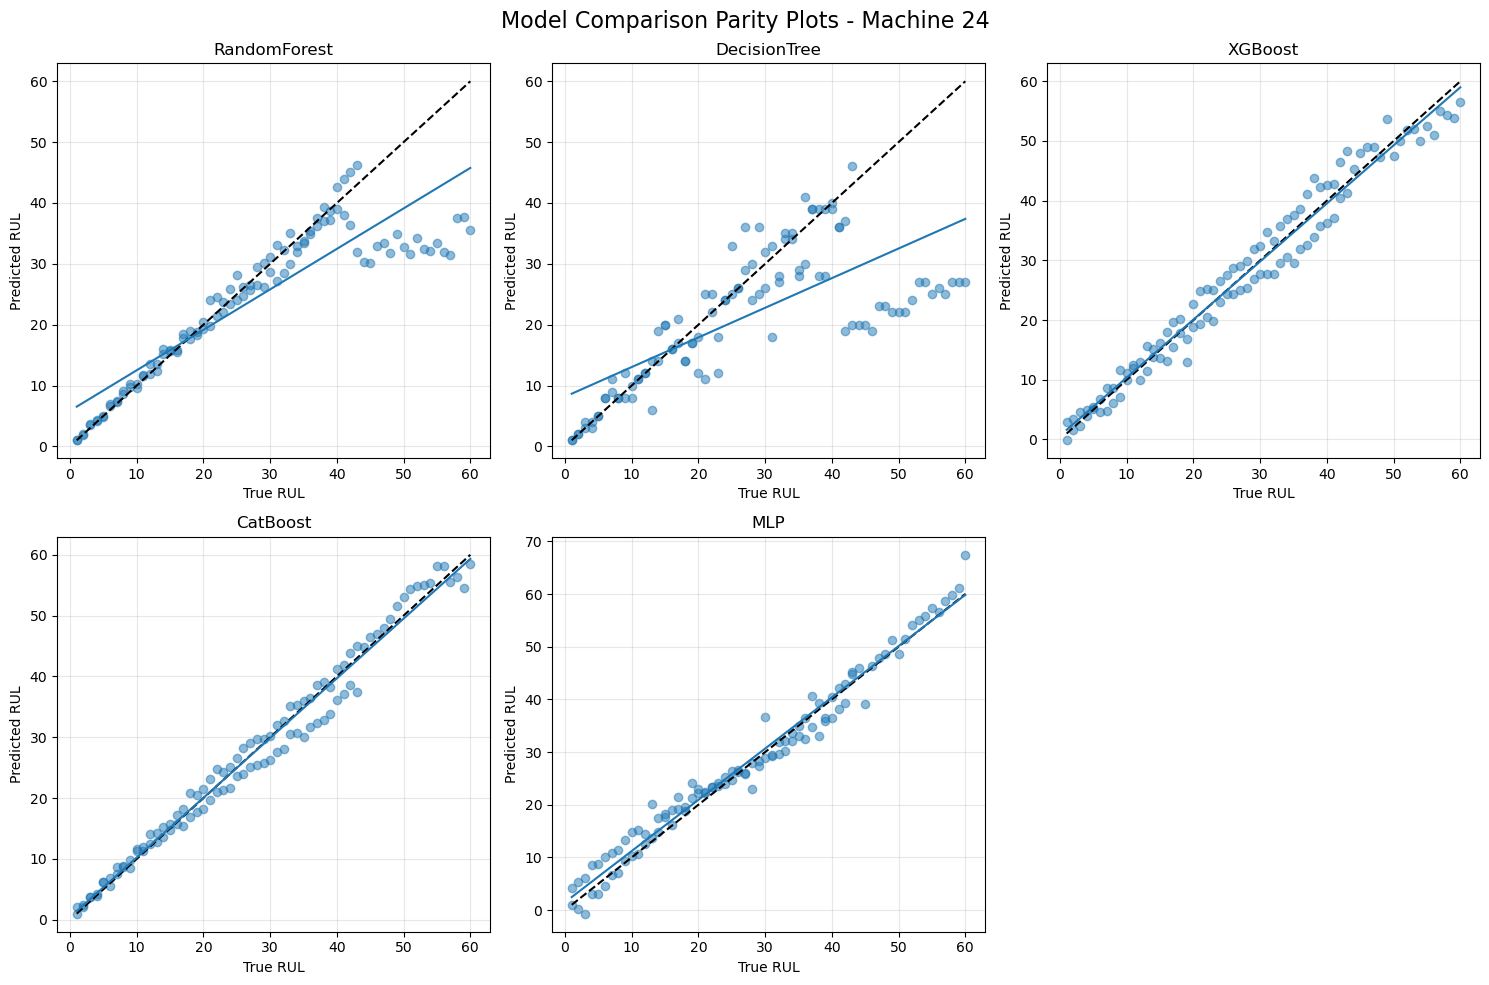

In [26]:
fig_24h, axes_24h = plt.subplots(2, 3, figsize=(15,10))
axes_24h = axes_24h.flatten()


line_x = np.linspace(y_true.min(), y_true.max(), 100)

for i, model in enumerate(model_names):

    ax_24h = axes_24h[i]

    y_pred = df_plot[f'{model}_predictions_24h'].values

    coef = np.polyfit(y_true, y_pred, 1)
    line_y = coef[0] * line_x + coef[1]

    ax_24h.scatter(y_true, y_pred, alpha=0.5)

    ax_24h.plot(line_x, line_x, '--', color='black') 
    ax_24h.plot(line_x, line_y)

    ax_24h.set_title(model)
    ax_24h.set_xlabel("True RUL")
    ax_24h.set_ylabel("Predicted RUL")
    ax_24h.grid(alpha=0.3)


fig_24h.delaxes(axes_24h[5])

plt.suptitle(f"Model Comparison Parity Plots - Machine {machine_id}", fontsize=16)
plt.tight_layout()
fig_24h.savefig("machine_unknown_scatter_plots_24h_data.pdf", dpi=300, bbox_inches="tight")

plt.show()

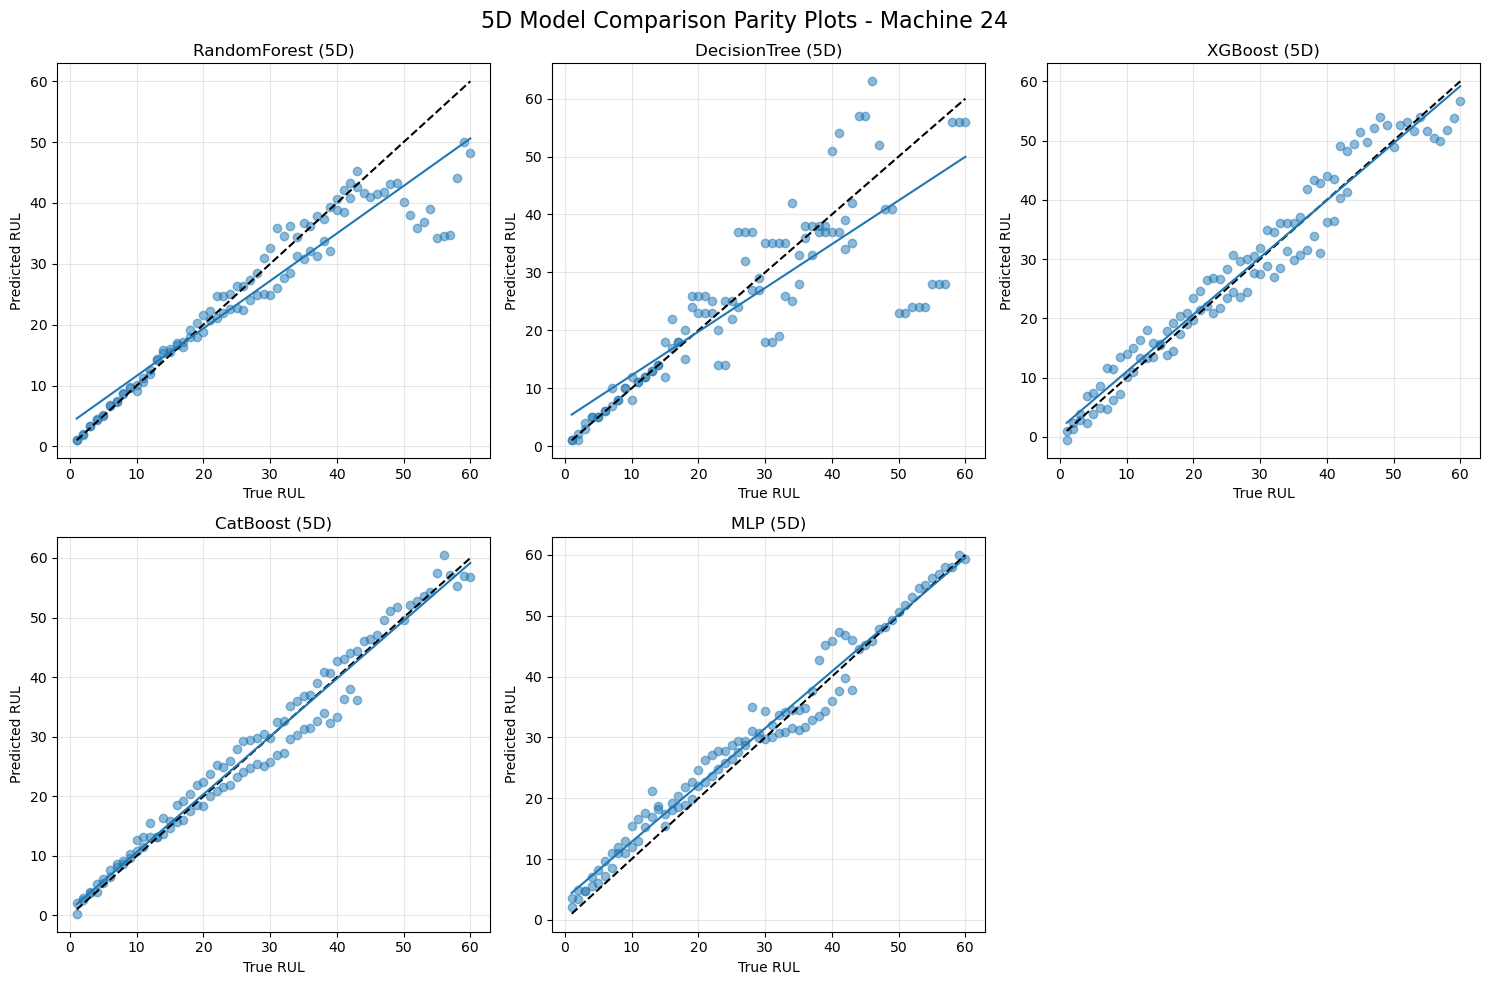

In [27]:
fig_5d, axes_5d = plt.subplots(2, 3, figsize=(15,10))
axes_5d = axes_5d.flatten()
line_x = np.linspace(y_true.min(), y_true.max(), 100)
for i, model in enumerate(model_names):

    ax_5d = axes_5d[i]


    y_pred = df_plot[f'{model}_predictions_5d'].values
    coef = np.polyfit(y_true, y_pred, 1)
    line_y = coef[0] * line_x + coef[1]

    ax_5d.scatter(y_true, y_pred, alpha=0.5)

    ax_5d.plot(line_x, line_x, '--', color='black')   
    ax_5d.plot(line_x, line_y)

    ax_5d.set_title(model + " (5D)")
    ax_5d.set_xlabel("True RUL")
    ax_5d.set_ylabel("Predicted RUL")
    ax_5d.grid(alpha=0.3)
fig_5d.delaxes(axes_5d[5])

plt.suptitle(f"5D Model Comparison Parity Plots - Machine {machine_id}", fontsize=16)
plt.tight_layout()
fig_5d.savefig("machine_unknown_scatter_plots_5d_data.pdf", dpi=300, bbox_inches="tight")

plt.show()

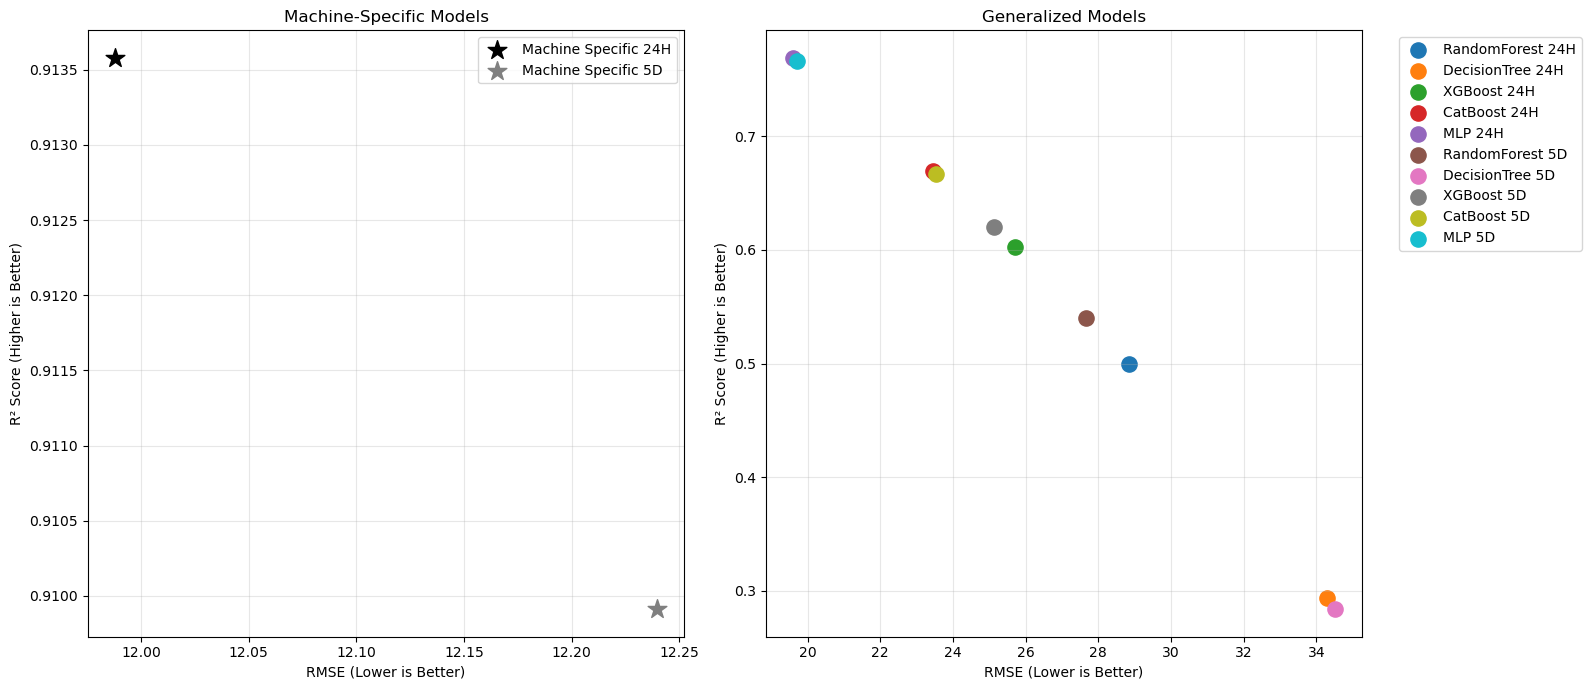

In [27]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16,7))

# ============================================================
# LEFT → Machine Specific Models
# ============================================================

ax = axes[0]

# Machine Specific 24H
ax.scatter(rmse_ms_24, r2_ms_24,
           color="black",
           s=200,
           marker="*",
           label="Machine Specific 24H")

# Machine Specific 5D
ax.scatter(rmse_ms_5, r2_ms_5,
           color="gray",
           s=200,
           marker="*",
           label="Machine Specific 5D")

ax.set_xlabel("RMSE (Lower is Better)")
ax.set_ylabel("R² Score (Higher is Better)")
ax.set_title("Machine-Specific Models")
ax.grid(alpha=0.3)
ax.legend()


# ============================================================
# RIGHT → All Generalized Models
# ============================================================

ax = axes[1]

# Generalized 24H
for model in results_general_24h_df.index:

    rmse = results_general_24h_df.loc[model, "RMSE"]
    r2 = results_general_24h_df.loc[model, "R2"]

    ax.scatter(rmse, r2,
               s=120,
               label=f"{model} 24H")

# Generalized 5D
for model in results_general_5d_df.index:

    rmse = results_general_5d_df.loc[model, "RMSE"]
    r2 = results_general_5d_df.loc[model, "R2"]

    ax.scatter(rmse, r2,
               s=120,
               label=f"{model} 5D")

ax.set_xlabel("RMSE (Lower is Better)")
ax.set_ylabel("R² Score (Higher is Better)")
ax.set_title("Generalized Models")
ax.grid(alpha=0.3)
ax.legend(bbox_to_anchor=(1.05,1), loc='upper left')

plt.tight_layout()
plt.savefig("ALL_MODELS_R2_SCORES.pdf", dpi=300, bbox_inches="tight")
plt.show()

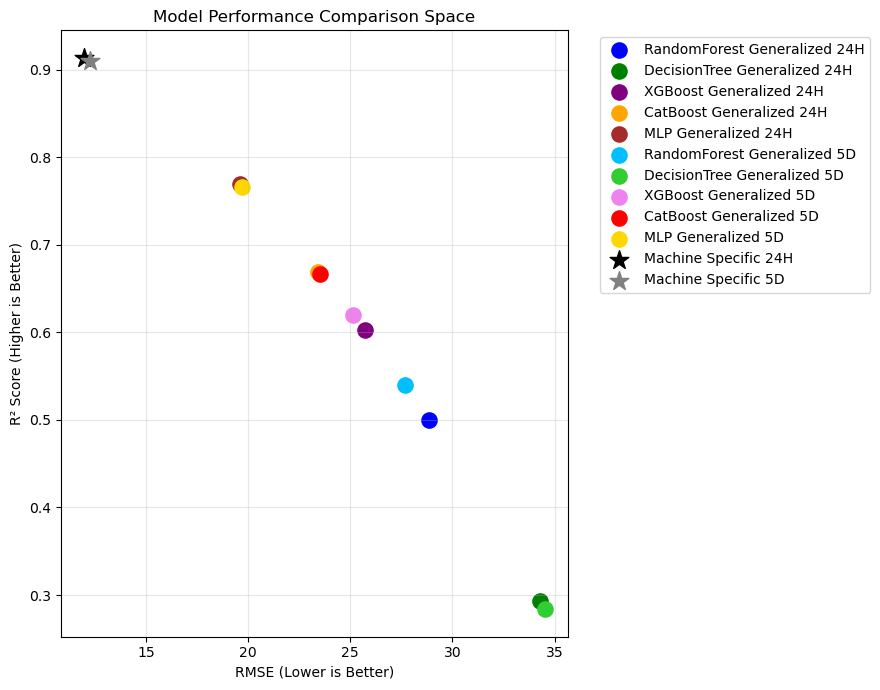

In [26]:
plt.figure(figsize=(9,7))
colors = {
    "RandomForest_24": "blue",
    "DecisionTree_24": "green",
    "XGBoost_24": "purple",
    "CatBoost_24": "orange",
    "MLP_24": "brown",

    "RandomForest_5": "deepskyblue",
    "DecisionTree_5": "limegreen",
    "XGBoost_5": "violet",
    "CatBoost_5": "red",
    "MLP_5": "gold",

    "MachineSpecific_24": "black",
    "MachineSpecific_5": "gray"
}

# ============================
# Generalized 24H Models
# ============================

for model in results_general_24h_df.index:

    rmse = results_general_24h_df.loc[model, "RMSE"]
    r2 = results_general_24h_df.loc[model, "R2"]

    plt.scatter(
        rmse,
        r2,
        color=colors.get(model + "_24", "blue"),
        s=120,
        label=f"{model} Generalized 24H"
    )

# ============================
# Generalized 5D Models
# ============================

for model in results_general_5d_df.index:

    rmse = results_general_5d_df.loc[model, "RMSE"]
    r2 = results_general_5d_df.loc[model, "R2"]

    plt.scatter(
        rmse,
        r2,
        color=colors.get(model + "_5", "red"),
        s=120,
        label=f"{model} Generalized 5D"
    )

# ============================
# Machine Specific CatBoost
# ============================

rmse_ms_24 = results_df.loc[results_df["Metric"]=="RMSE","24H Model"].values[0]
r2_ms_24 = results_df.loc[results_df["Metric"]=="R2 Score","24H Model"].values[0]

rmse_ms_5 = results_df.loc[results_df["Metric"]=="RMSE","5D Model"].values[0]
r2_ms_5 = results_df.loc[results_df["Metric"]=="R2 Score","5D Model"].values[0]

plt.scatter(rmse_ms_24, r2_ms_24,
            color="black",
            s=200,
            marker="*",
            label="Machine Specific 24H")

plt.scatter(rmse_ms_5, r2_ms_5,
            color="gray",
            s=200,
            marker="*",
            label="Machine Specific 5D")

# ============================
# Formatting
# ============================

plt.xlabel("RMSE (Lower is Better)")
plt.ylabel("R² Score (Higher is Better)")
plt.title("Model Performance Comparison Space")

plt.grid(alpha=0.3)
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')

plt.tight_layout()
plt.show()

C:\Users\ismai\anaconda3\envs\project_clean\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\ismai\anaconda3\envs\project_clean\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
C:\Users\ismai\anaconda3\envs\project_clean\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but MLPRegressor was fitted with feature names
  warnings.warn(
C:\Users\ismai\anaconda3\envs\project_clean\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\ismai\anaconda3\envs\project_clean\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature na

Baseline Results
                    MAE          MSE       RMSE        R2
RandomForest  15.886995   831.721441  28.839581  0.499837
DecisionTree  19.248018  1175.046043  34.278945  0.293376
XGBoost       14.676061   660.807756  25.706181  0.602617
CatBoost      13.639993   549.615204  23.443873  0.669484
MLP           12.326784   384.144405  19.599602  0.768991


C:\Users\ismai\anaconda3\envs\project_clean\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but MLPRegressor was fitted with feature names
  warnings.warn(
C:\Users\ismai\anaconda3\envs\project_clean\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\ismai\anaconda3\envs\project_clean\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
C:\Users\ismai\anaconda3\envs\project_clean\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but MLPRegressor was fitted with feature names
  warnings.warn(
C:\Users\ismai\anaconda3\envs\project_clean\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  war

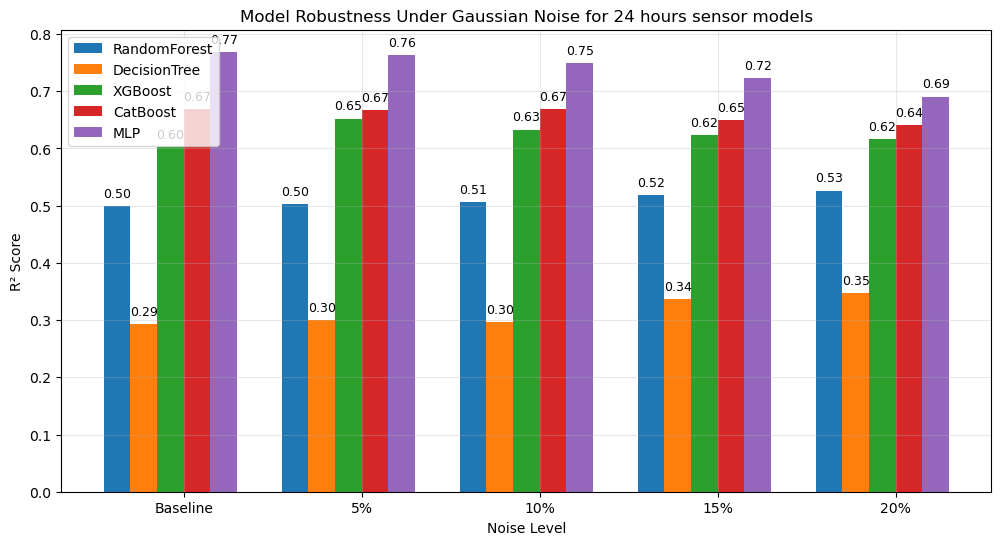

In [29]:
# ---------- Train Generalized Models ----------
trained_models_24h = {}

for name_24h, model_24h in models_dict.items():

    model_clone_24h = deepcopy(model_24h)
    model_clone_24h.fit(train_24_general, train_general)

    trained_models_24h[name_24h] = model_clone_24h


# ---------- Baseline Performance ----------
baseline_results_24h = {}

X_test_24h = test_24_general.values
y_test_24h = test_general.values

for name, model in trained_models_24h.items():

    pred_24h = model.predict(X_test_24h)

    mae_24h = mean_absolute_error(y_test_24h, pred_24h)
    mse_24h = mean_squared_error(y_test_24h, pred_24h)
    rmse_24h = np.sqrt(mse_24h)
    r2_24h = r2_score(y_test_24h, pred_24h)

    baseline_results_24h[name] = {
        "MAE": mae_24h,
        "MSE": mse_24h,
        "RMSE": rmse_24h,
        "R2": r2_24h
    }

baseline_df_24h = pd.DataFrame(baseline_results_24h).T

print("Baseline Results")
print(baseline_df_24h)



noise_levels = [0.05, 0.1, 0.15, 0.2]
feature_std_24h = X_test_24h.std(axis=0)

# Store predictions
test_noise_predictions_24h = {}

# Store metrics
results_noise_24h = {}

for noise in noise_levels:

    noise_matrix_24h = np.random.normal(0, 1, X_test_24h.shape)
    test_noisy_24h = X_test_24h + noise * noise_matrix_24h * feature_std_24h

    noise_label_24h = f"{int(noise*100)}%"

    results_noise_24h[noise_label_24h] = {}

    for name_24h, model_24h in trained_models_24h.items():

        pred_24h = model_24h.predict(test_noisy_24h)

        # ---------- Save Predictions ----------
        column_name_24h = f"{name_24h}_predictions_24h_{noise_label_24h}"
        test_noise_predictions_24h[column_name_24h] = pred_24h

        # ---------- Calculate Metrics ----------
        mae_24h = mean_absolute_error(y_test_24h, pred_24h)
        mse_24h = mean_squared_error(y_test_24h, pred_24h)
        rmse_24h = np.sqrt(mse_24h)
        r2_24h = r2_score(y_test_24h, pred_24h)

        results_noise_24h[noise_label_24h][name_24h] = {
            "MAE": mae_24h,
            "MSE": mse_24h,
            "RMSE": rmse_24h,
            "R2": r2_24h
        }

noise_results_df_24h = {}

for metric in ["MAE", "MSE", "RMSE", "R2"]:

    temp_24h = {}

    for noise in results_noise_24h:

        temp_24h[noise] = {
            model_24h: results_noise_24h[noise][model_24h][metric]
            for model_24h in trained_models_24h
        }

    noise_results_df_24h[metric] = pd.DataFrame(temp_24h).T
# ---------- Prepare Plot Data ----------
models_24h = list(trained_models_24h.keys())

r2_data_24h = []

for model_24h in models_24h:

    r2_data_24h.append(
        [baseline_results_24h[model_24h]["R2"]] +
        [noise_results_df_24h["R2"].loc[f"{int(n*100)}%", model_24h] for n in noise_levels]
    )

r2_data_24h = np.array(r2_data_24h)


# ---------- Bar Plot ----------
plt.figure(figsize=(12,6))

width = 0.15
x = np.arange(len(noise_levels) + 1)

colors = plt.cm.tab10.colors

for i_24h, model_24h in enumerate(models_24h):

    bars = plt.bar(
        x + i_24h * width,
        r2_data_24h[i_24h],
        width,
        label=model_24h,
        color=colors[i_24h]
    )
    # Add values on top of bars
    for j, bar in enumerate(bars):
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.01,
            f"{height:.2f}",
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.xticks(
    x + width*(len(models_24h)/2),
    ["Baseline"] + [f"{int(n*100)}%" for n in noise_levels]
)

plt.ylabel("R² Score")
plt.xlabel("Noise Level")
plt.title("Model Robustness Under Gaussian Noise for 24 hours sensor models")

plt.legend()
plt.grid(alpha=0.3)
plt.savefig("Model_Robustness_Under_Gaussian_Noise_for_24_hours_sensor_models.pdf", dpi=300, bbox_inches="tight")
plt.show()

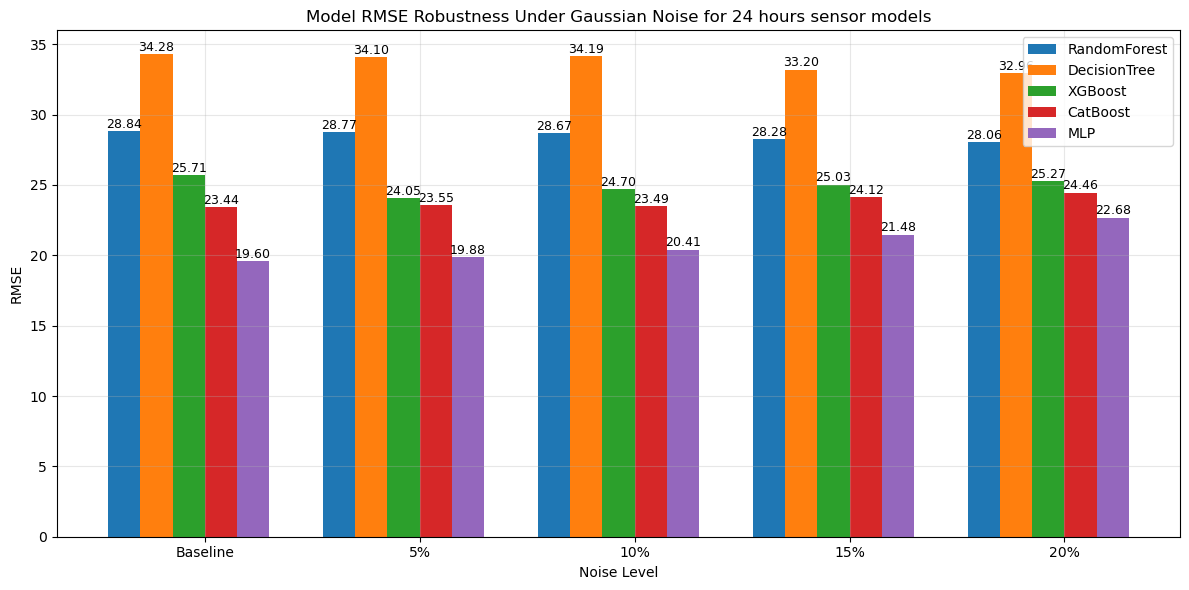

In [30]:
# ---------- Prepare RMSE Plot Data ----------
models_24h = list(trained_models_24h.keys())

rmse_data_24h = []

for model_24h in models_24h:

    rmse_data_24h.append(
        [baseline_results_24h[model_24h]["RMSE"]] +
        [noise_results_df_24h["RMSE"].loc[f"{int(n*100)}%", model_24h] for n in noise_levels]
    )

rmse_data_24h = np.array(rmse_data_24h)


# ---------- RMSE Bar Plot ----------
plt.figure(figsize=(12,6))

width = 0.15
x = np.arange(len(noise_levels) + 1)

colors = plt.cm.tab10.colors

for i_24h, model_24h in enumerate(models_24h):

    bars = plt.bar(
        x + i_24h * width,
        rmse_data_24h[i_24h],
        width,
        label=model_24h,
        color=colors[i_24h]
    )

    # Add values on top of bars
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.01,
            f"{height:.2f}",
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.xticks(
    x + width*(len(models_24h)/2),
    ["Baseline"] + [f"{int(n*100)}%" for n in noise_levels]
)

plt.ylabel("RMSE")
plt.xlabel("Noise Level")
plt.title("Model RMSE Robustness Under Gaussian Noise for 24 hours sensor models")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("Model_RMSE_Robustness_Under_Gaussian_Noise_for_24_hours_sensor_models.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [31]:
# Convert to DataFrame
predictions_noise_df = pd.DataFrame(test_noise_predictions_24h)

# Combine with original test set
test_with_noise_predictions_24h = pd.concat(
    [test.reset_index(drop=True), predictions_noise_df],
    axis=1
)

In [32]:
from sklearn.metrics import r2_score

per_machine_r2_list = []

noise_levels = ["0%", "5%", "10%", "15%", "20%"]  # include baseline as 0%

for noise in noise_levels:

    for model_name in models_dict.keys():

        # prediction column name
        if noise == "0%":
            pred_col = f"{model_name}_predictions_24h"
        else:
            pred_col = f"{model_name}_predictions_24h_{noise}"

        # compute R2 per machine
        for machine_id, group in test_with_noise_predictions_24h.groupby("machineID"):

            y_true = group["RUL"]   # <-- change if your target column has different name
            y_pred = group[pred_col]

            r2 = r2_score(y_true, y_pred)

            per_machine_r2_list.append({
                "MachineID": machine_id,
                "Model": model_name,
                "Noise": noise,
                "R2": r2
            })

per_machine_r2_df = pd.DataFrame(per_machine_r2_list)

per_machine_r2_24h = per_machine_r2_df.pivot_table(
    index=["MachineID", "Model"],
    columns="Noise",
    values="R2"
).reset_index()

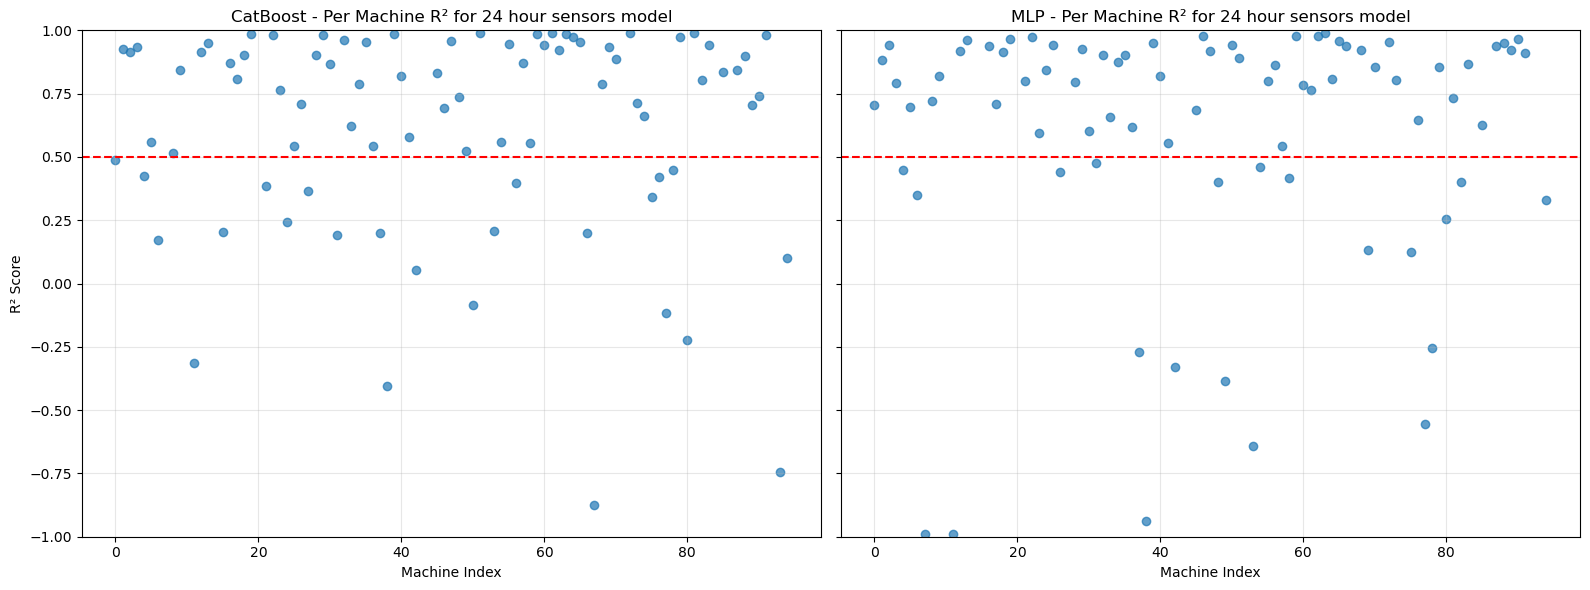

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# Filter baseline data (0% noise)
baseline = per_machine_r2_df[per_machine_r2_df["Noise"] == "0%"]

# Extract model-specific R2 values
mlp_r2 = baseline[baseline["Model"] == "CatBoost"]["R2"].values
xgb_r2 = baseline[baseline["Model"] == "MLP"]["R2"].values

machines = np.arange(len(mlp_r2))

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(16,6), sharey=True)

# ---- MLP Plot ----
axes[0].scatter(machines, mlp_r2, alpha=0.7)
axes[0].axhline(0.5, linestyle="--", color="red")
axes[0].set_title("CatBoost - Per Machine R² for 24 hour sensors model")
axes[0].set_xlabel("Machine Index")
axes[0].set_ylabel("R² Score")
axes[0].grid(alpha=0.3)

# ---- XGBoost Plot ----
axes[1].scatter(machines, xgb_r2, alpha=0.7)
axes[1].axhline(0.5, linestyle="--", color="red")
axes[1].set_title("MLP - Per Machine R² for 24 hour sensors model")
axes[1].set_xlabel("Machine Index")
axes[1].grid(alpha=0.3)

# Same y-axis range
axes[0].set_ylim(-1, 1)

plt.tight_layout()
plt.savefig("Per_Machine_R²_for_24_hour_sensors_model.pdf", dpi=300, bbox_inches="tight")
plt.show()

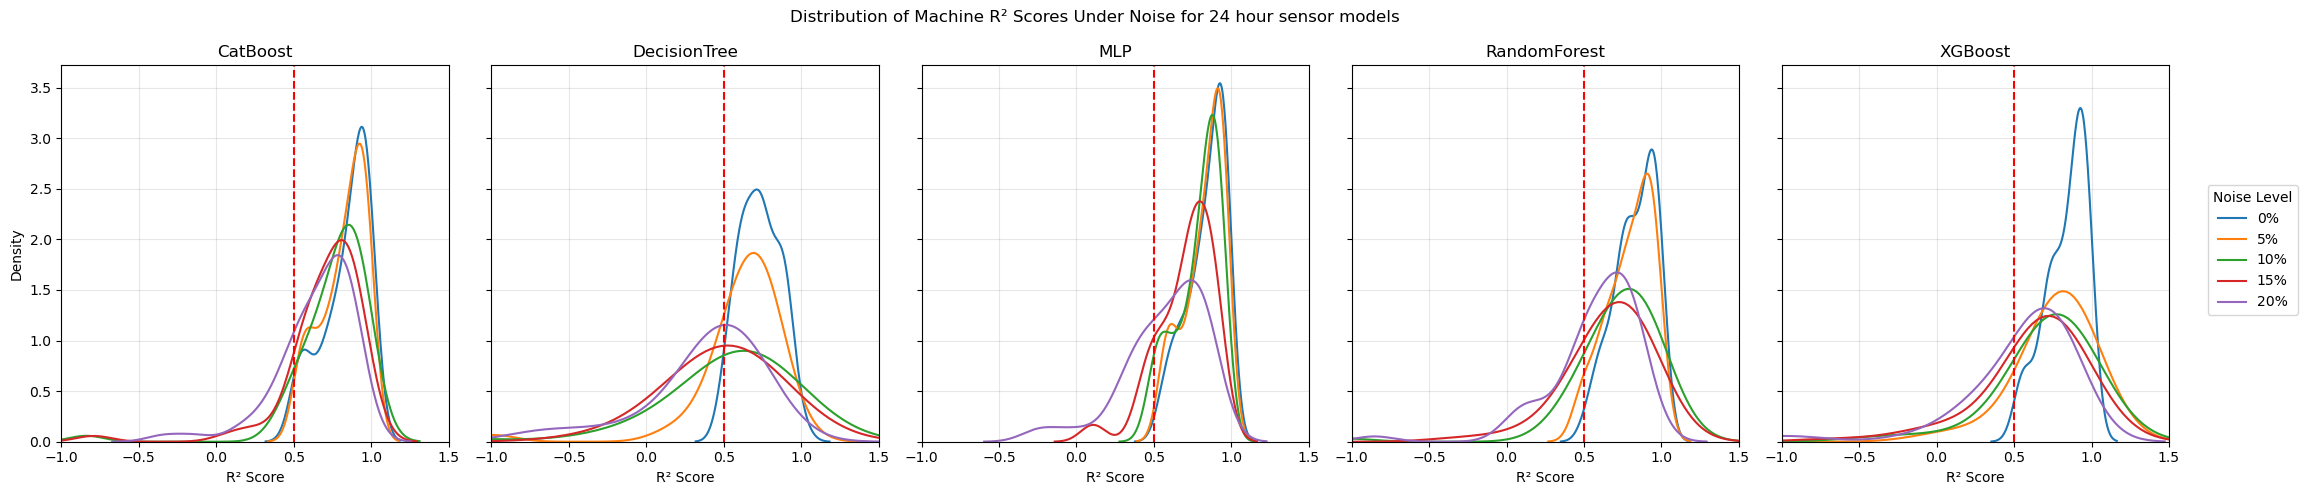

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

noise_cols = ["0%", "5%", "10%", "15%", "20%"]
models = per_machine_r2_24h["Model"].unique()

fig, axes = plt.subplots(1, len(models), figsize=(22,5), sharey=True)

for i, model in enumerate(models):

    model_df = per_machine_r2_24h[per_machine_r2_24h["Model"] == model]

    # keep machines with baseline R² > 0.5
    filtered_df = model_df[model_df["0%"] > 0.5]

    for noise in noise_cols:
        sns.kdeplot(
            filtered_df[noise],
            label=noise,
            ax=axes[i]
        )

    axes[i].axvline(0.5, linestyle="--", color="red")
    axes[i].set_title(model)
    axes[i].set_xlabel("R² Score")
    axes[i].set_xlim(-1, 1.5)
    axes[i].grid(alpha=0.3)

axes[0].set_ylabel("Density")

# ---- Single Legend Outside ----
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title="Noise Level",
    loc="center right",
    bbox_to_anchor=(1.05, 0.5)
)

# remove subplot legends
for ax in axes:
    ax.legend().remove()

plt.suptitle("Distribution of Machine R² Scores Under Noise for 24 hour sensor models")
plt.tight_layout()
plt.savefig("Distribution_of_Machine_R²_Scores_Under_Noise_for_24_hour_sensor_models.pdf", dpi=300, bbox_inches="tight")
plt.show()

C:\Users\ismai\AppData\Local\Temp\ipykernel_11464\3850665630.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(data, labels=noise_cols)
C:\Users\ismai\AppData\Local\Temp\ipykernel_11464\3850665630.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(data, labels=noise_cols)
C:\Users\ismai\AppData\Local\Temp\ipykernel_11464\3850665630.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(data, labels=noise_cols)
C:\Users\ismai\AppData\Local\Temp\ipykernel_11464\3850665630.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_lab

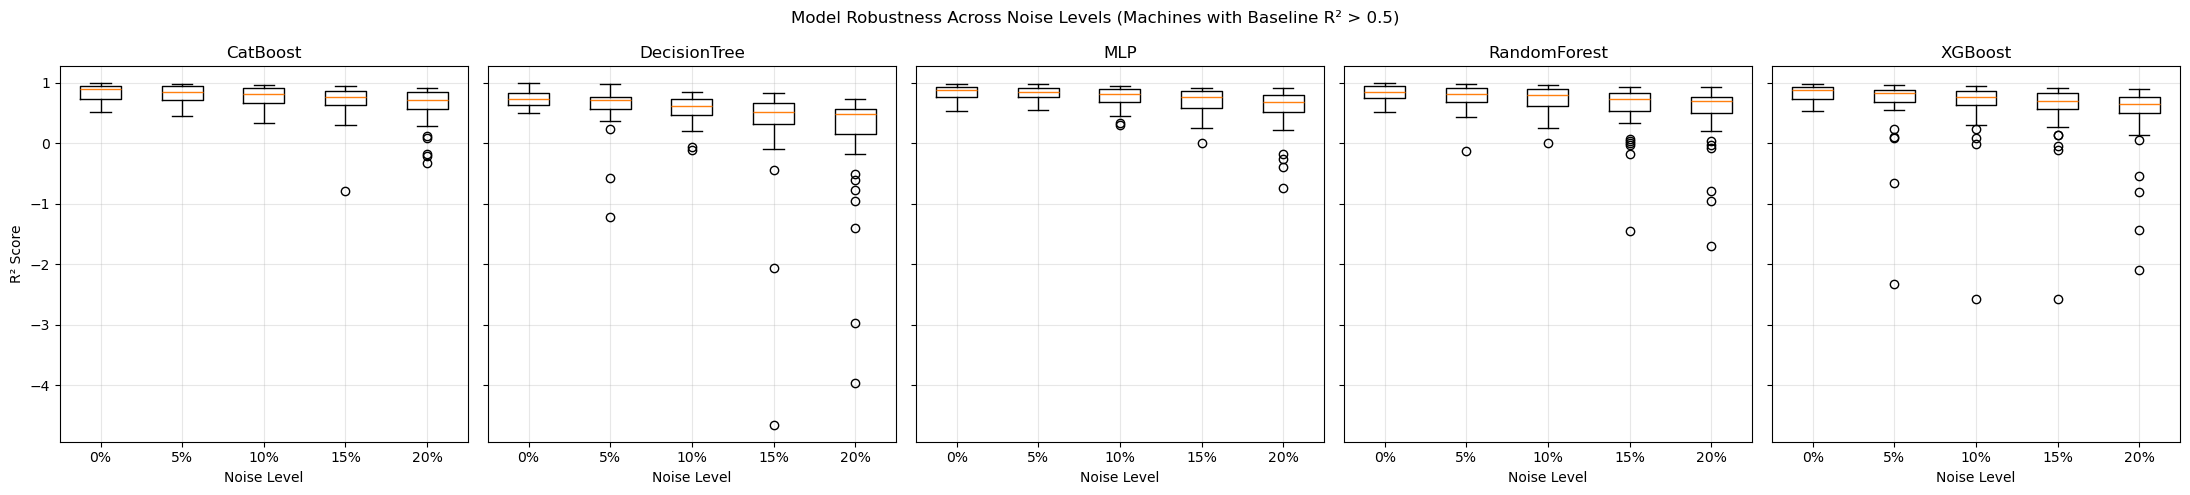

In [38]:
import matplotlib.pyplot as plt

noise_cols = ["0%", "5%", "10%", "15%", "20%"]
models = per_machine_r2_24h["Model"].unique()

fig, axes = plt.subplots(1, len(models), figsize=(22,5), sharey=True)

for i, model in enumerate(models):

    # Select model
    model_df = per_machine_r2_24h[per_machine_r2_24h["Model"] == model]

    # Filter machines with baseline R² > 0.5
    filtered_df = model_df[model_df["0%"] > 0.5]

    # Collect data for boxplot
    data = [filtered_df[col] for col in noise_cols]

    axes[i].boxplot(data, labels=noise_cols)

    axes[i].set_title(model)
    axes[i].set_xlabel("Noise Level")
    axes[i].grid(alpha=0.3)

axes[0].set_ylabel("R² Score")

plt.suptitle("Boxplots of Model Robustness Across Noise Levels (Machines with Baseline R² > 0.5)")
plt.tight_layout()
plt.show()

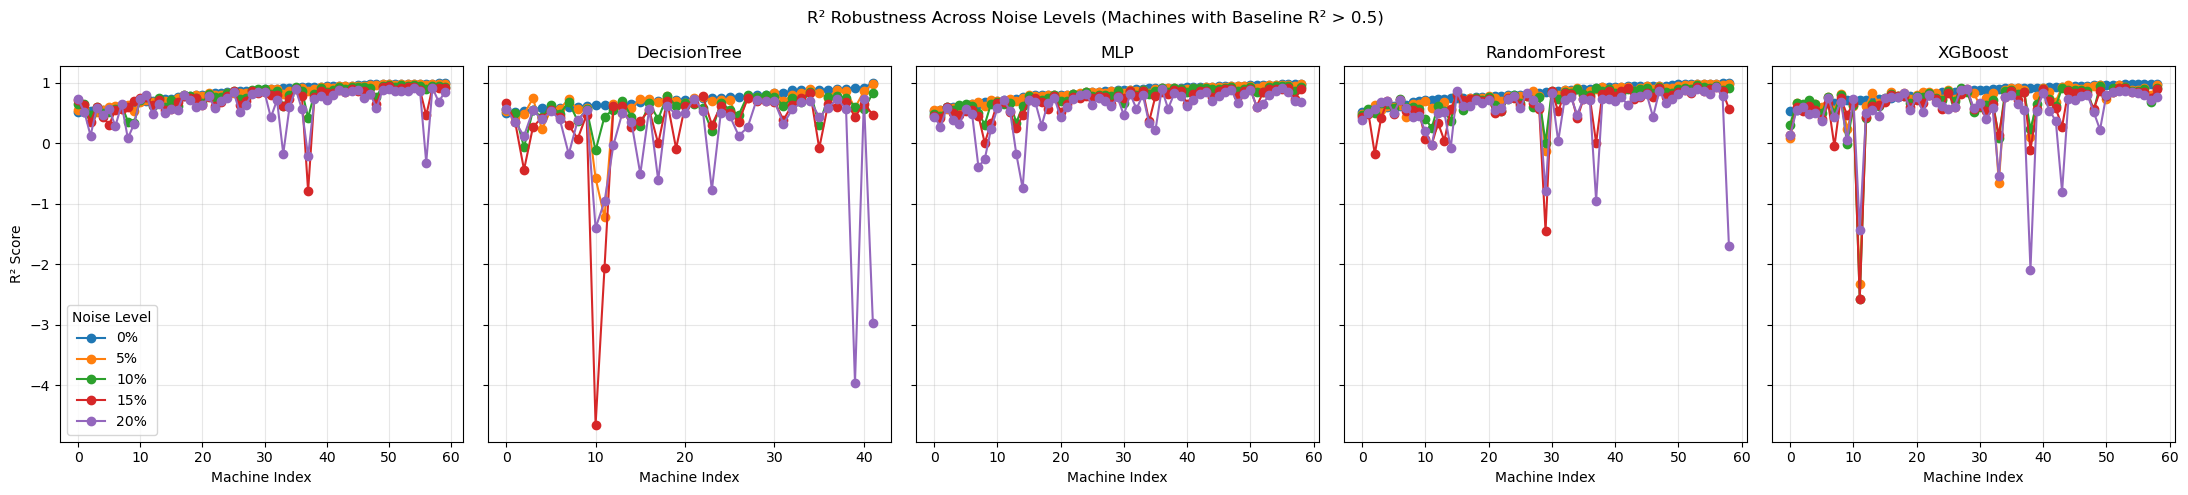

In [47]:
import matplotlib.pyplot as plt

noise_cols = ["0%", "5%", "10%", "15%", "20%"]
models = per_machine_r2_24h["Model"].unique()

fig, axes = plt.subplots(1, len(models), figsize=(22,5), sharey=True)

for i, model in enumerate(models):

    # Select model data
    model_df = per_machine_r2_24h[per_machine_r2_24h["Model"] == model]

    # Filter machines with baseline R2 > 0.5
    filtered_df = model_df[model_df["0%"] > 0.5]

    # Sort machines for cleaner lines
    filtered_df = filtered_df.sort_values("0%").reset_index(drop=True)

    # X-axis = machine index
    x = range(len(filtered_df))

    # Plot each noise level
    for noise in noise_cols:
        axes[i].plot(
            x,
            filtered_df[noise],
            marker="o",
            label=noise
        )

    axes[i].set_title(model)
    axes[i].set_xlabel("Machine Index")
    axes[i].grid(alpha=0.3)

axes[0].set_ylabel("R² Score")
axes[0].legend(title="Noise Level")

plt.suptitle("R² Robustness Across Noise Levels (Machines with Baseline R² > 0.5)")
plt.tight_layout()
plt.show()

C:\Users\ismai\anaconda3\envs\project_clean\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\ismai\anaconda3\envs\project_clean\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
C:\Users\ismai\anaconda3\envs\project_clean\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but MLPRegressor was fitted with feature names
  warnings.warn(
C:\Users\ismai\anaconda3\envs\project_clean\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\ismai\anaconda3\envs\project_clean\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature na

Baseline Results
                    MAE          MSE       RMSE        R2
RandomForest  15.349529   765.305726  27.664160  0.539777
DecisionTree  19.537210  1190.899569  34.509413  0.283842
XGBoost       14.605198   632.128602  25.142168  0.619864
CatBoost      13.845061   553.813770  23.533248  0.666959
MLP           12.715581   388.857346  19.719466  0.766157


C:\Users\ismai\anaconda3\envs\project_clean\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but MLPRegressor was fitted with feature names
  warnings.warn(
C:\Users\ismai\anaconda3\envs\project_clean\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\ismai\anaconda3\envs\project_clean\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
C:\Users\ismai\anaconda3\envs\project_clean\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but MLPRegressor was fitted with feature names
  warnings.warn(
C:\Users\ismai\anaconda3\envs\project_clean\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  war

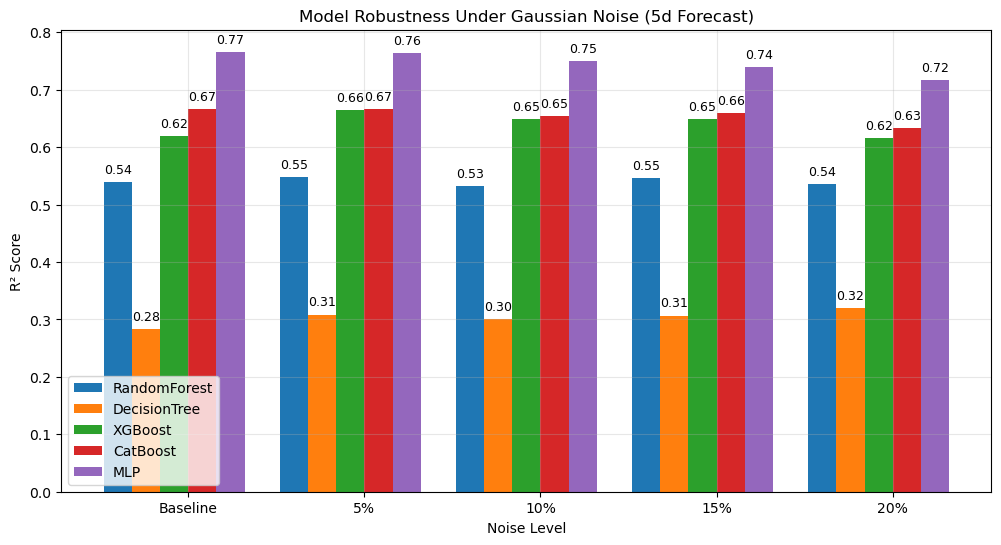

In [35]:
# ---------- Train Generalized Models ----------
trained_models_5d = {}

for name_5d, model_5d in models_dict.items():

    model_clone_5d = deepcopy(model_5d)
    model_clone_5d.fit(train_5_general, train_general)

    trained_models_5d[name_5d] = model_clone_5d


# ---------- Baseline Performance ----------
baseline_results_5d = {}

X_test_5d = test_5_general.values
y_test_5d = test_general.values

for name_5d, model_5d in trained_models_5d.items():

    pred_5d = model_5d.predict(X_test_5d)

    mae_5d = mean_absolute_error(y_test_5d, pred_5d)
    mse_5d = mean_squared_error(y_test_5d, pred_5d)
    rmse_5d = np.sqrt(mse_5d)
    r2_5d = r2_score(y_test_5d, pred_5d)

    baseline_results_5d[name_5d] = {
        "MAE": mae_5d,
        "MSE": mse_5d,
        "RMSE": rmse_5d,
        "R2": r2_5d
    }

baseline_df_5d = pd.DataFrame.from_dict(baseline_results_5d, orient="index")

print("Baseline Results")
print(baseline_df_5d)


# ---------- Robustness Testing ----------
np.random.seed(42)

noise_levels = [0.05, 0.1, 0.15, 0.2]
feature_std_5d = X_test_5d.std(axis=0)

test_noise_predictions_5d = {}
results_noise_5d = {}

for noise in noise_levels:

    noise_matrix_5d = np.random.normal(0, 1, X_test_5d.shape)
    test_noisy_5d = X_test_5d + noise * noise_matrix_5d * feature_std_5d

    noise_label_5d = f"{int(noise*100)}%"
    results_noise_5d[noise_label_5d] = {}

    for name_5d, model_5d in trained_models_5d.items():

        pred_5d = model_5d.predict(test_noisy_5d)

        column_name_5d = f"{name_5d}_predictions_5d_{noise_label_5d}"
        test_noise_predictions_5d[column_name_5d] = pred_5d

        mae_5d = mean_absolute_error(y_test_5d, pred_5d)
        mse_5d = mean_squared_error(y_test_5d, pred_5d)
        rmse_5d = np.sqrt(mse_5d)
        r2_5d = r2_score(y_test_5d, pred_5d)

        results_noise_5d[noise_label_5d][name_5d] = {
            "MAE": mae_5d,
            "MSE": mse_5d,
            "RMSE": rmse_5d,
            "R2": r2_5d
        }


# ---------- Convert results to DataFrames ----------
noise_results_df_5d = {}

for metric in ["MAE", "MSE", "RMSE", "R2"]:

    temp_5d = {}

    for noise in results_noise_5d:
        temp_5d[noise] = {
            model_5d: results_noise_5d[noise][model_5d][metric]
            for model_5d in trained_models_5d
        }

    noise_results_df_5d[metric] = pd.DataFrame.from_dict(temp_5d, orient="index")


# ---------- Prepare Plot Data ----------
models_5d = list(trained_models_5d.keys())

r2_data_5d = []

for model_5d in models_5d:

    r2_data_5d.append(
        [baseline_results_5d[model_5d]["R2"]] +
        [noise_results_df_5d["R2"].loc[f"{int(n*100)}%", model_5d] for n in noise_levels]
    )

r2_data_5d = np.array(r2_data_5d)


# ---------- Bar Plot ----------
plt.figure(figsize=(12,6))

width = 0.16
x = np.arange(len(noise_levels) + 1)

colors = plt.cm.tab10.colors

for i_5d, model_5d in enumerate(models_5d):

    bars = plt.bar(
        x + i_5d * width,
        r2_data_5d[i_5d],
        width,
        label=model_5d,
        color=colors[i_5d]
    )

    # Add value labels
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.01,
            f"{height:.2f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.xticks(
    x + width*(len(models_5d)/2),
    ["Baseline"] + [f"{int(n*100)}%" for n in noise_levels]
)

plt.ylabel("R² Score")
plt.xlabel("Noise Level")
plt.title("Model Robustness Under Gaussian Noise (5d Forecast)")

plt.legend()
plt.grid(alpha=0.3)
plt.savefig("Distribution_of_Machine_R²_Scores_Under_Noise_for_5_days_sensor_models.pdf", dpi=300, bbox_inches="tight")
plt.show()

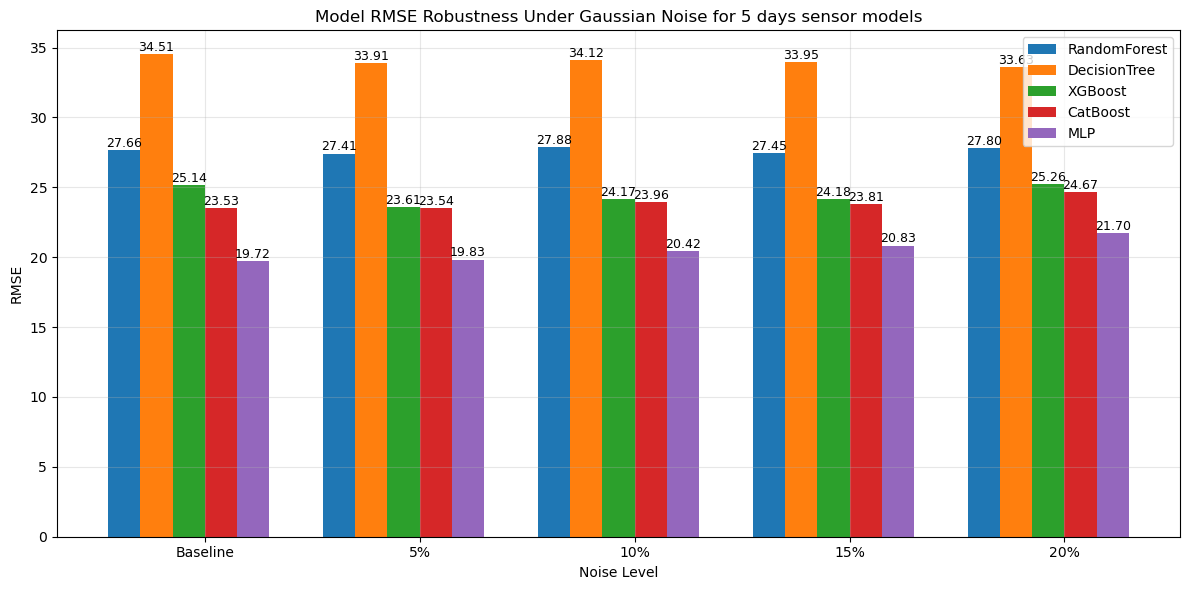

In [36]:
# ---------- Prepare RMSE Plot Data ----------
models_5d = list(trained_models_5d.keys())

rmse_data_5d = []

for model_5d in models_5d:

    rmse_data_5d.append(
        [baseline_results_5d[model_5d]["RMSE"]] +
        [noise_results_df_5d["RMSE"].loc[f"{int(n*100)}%", model_5d] for n in noise_levels]
    )

rmse_data_5d = np.array(rmse_data_5d)


# ---------- RMSE Bar Plot ----------
plt.figure(figsize=(12,6))

width = 0.15
x = np.arange(len(noise_levels) + 1)

colors = plt.cm.tab10.colors

for i_5d, model_5d in enumerate(models_5d):

    bars = plt.bar(
        x + i_5d * width,
        rmse_data_5d[i_5d],
        width,
        label=model_5d,
        color=colors[i_5d]
    )

    # Add values on top of bars
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.01,
            f"{height:.2f}",
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.xticks(
    x + width*(len(models_5d)/2),
    ["Baseline"] + [f"{int(n*100)}%" for n in noise_levels]
)

plt.ylabel("RMSE")
plt.xlabel("Noise Level")
plt.title("Model RMSE Robustness Under Gaussian Noise for 5 days sensor models")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("Model_RMSE_Robustness_Under_Gaussian_Noise_for_5_days_sensor_models.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [37]:
predictions_noise_df_5d = pd.DataFrame(test_noise_predictions_5d)

# Combine with original test set
test_with_noise_predictions_5d = pd.concat(
    [test.reset_index(drop=True), predictions_noise_df_5d],
    axis=1
)

In [38]:

per_machine_r2_list_5d = []

noise_levels = ["0%", "5%", "10%", "15%", "20%"]  # include baseline as 0%

for noise in noise_levels:

    for model_name in models_dict.keys():

        # prediction column name
        if noise == "0%":
            pred_col = f"{model_name}_predictions_5d"
        else:
            pred_col = f"{model_name}_predictions_5d_{noise}"

        # compute R2 per machine
        for machine_id, group in test_with_noise_predictions_5d.groupby("machineID"):

            y_true_5d = group["RUL"]   # <-- change if your target column has different name
            y_pred_5d = group[pred_col]

            r2 = r2_score(y_true_5d, y_pred_5d)

            per_machine_r2_list_5d.append({
                "MachineID": machine_id,
                "Model": model_name,
                "Noise": noise,
                "R2": r2
            })

per_machine_r2_df_5d = pd.DataFrame(per_machine_r2_list_5d)

per_machine_r2_5d = per_machine_r2_df_5d.pivot_table(
    index=["MachineID", "Model"],
    columns="Noise",
    values="R2"
).reset_index()

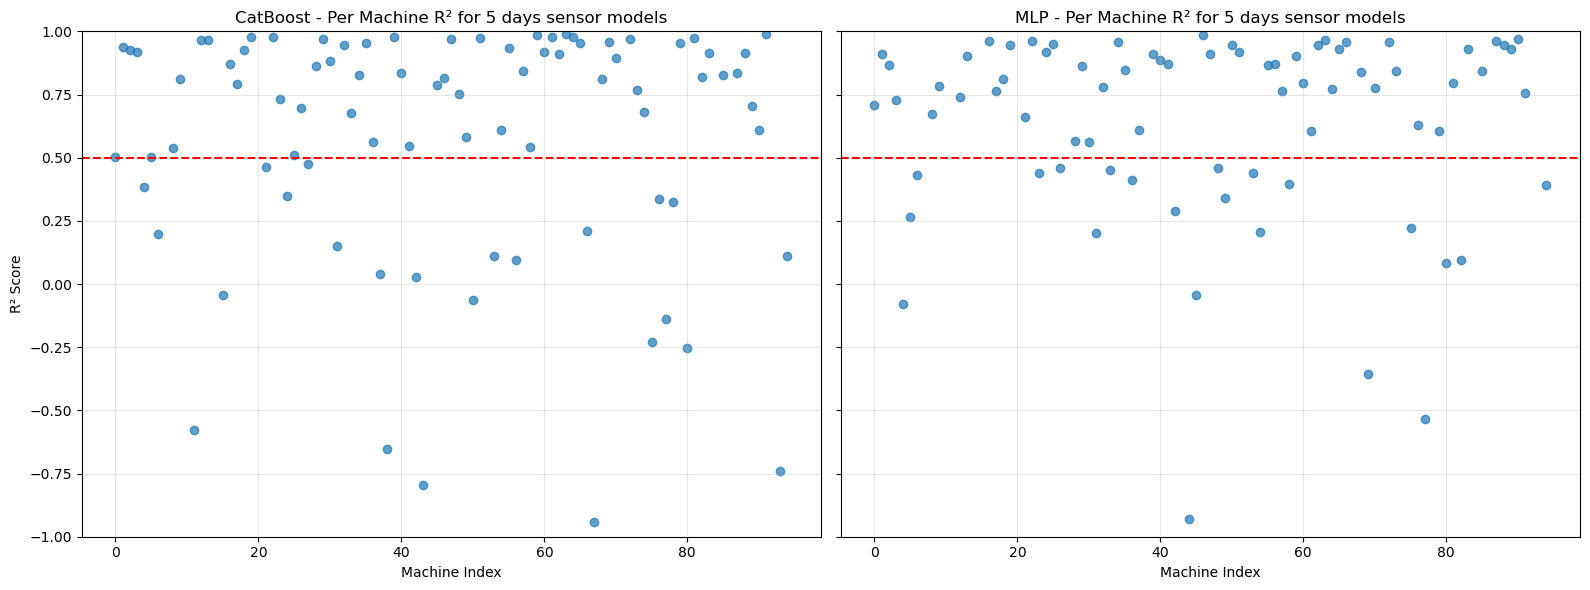

In [39]:

# Filter baseline data (0% noise)
baseline = per_machine_r2_df_5d[per_machine_r2_df_5d["Noise"] == "0%"]

# Extract model-specific R2 values
mlp_r2 = baseline[baseline["Model"] == "CatBoost"]["R2"].values
xgb_r2 = baseline[baseline["Model"] == "MLP"]["R2"].values

machines = np.arange(len(mlp_r2))

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(16,6), sharey=True)

# ---- MLP Plot ----
axes[0].scatter(machines, mlp_r2, alpha=0.7)
axes[0].axhline(0.5, linestyle="--", color="red")
axes[0].set_title("CatBoost - Per Machine R² for 5 days sensor models")
axes[0].set_xlabel("Machine Index")
axes[0].set_ylabel("R² Score")
axes[0].grid(alpha=0.3)

# ---- XGBoost Plot ----
axes[1].scatter(machines, xgb_r2, alpha=0.7)
axes[1].axhline(0.5, linestyle="--", color="red")
axes[1].set_title("MLP - Per Machine R² for 5 days sensor models")
axes[1].set_xlabel("Machine Index")
axes[1].grid(alpha=0.3)

# Same y-axis range
axes[0].set_ylim(-1, 1)

plt.tight_layout()
plt.savefig("Per_Machine_R²_for_5_days_sensor_models.pdf", dpi=300, bbox_inches="tight")
plt.show()

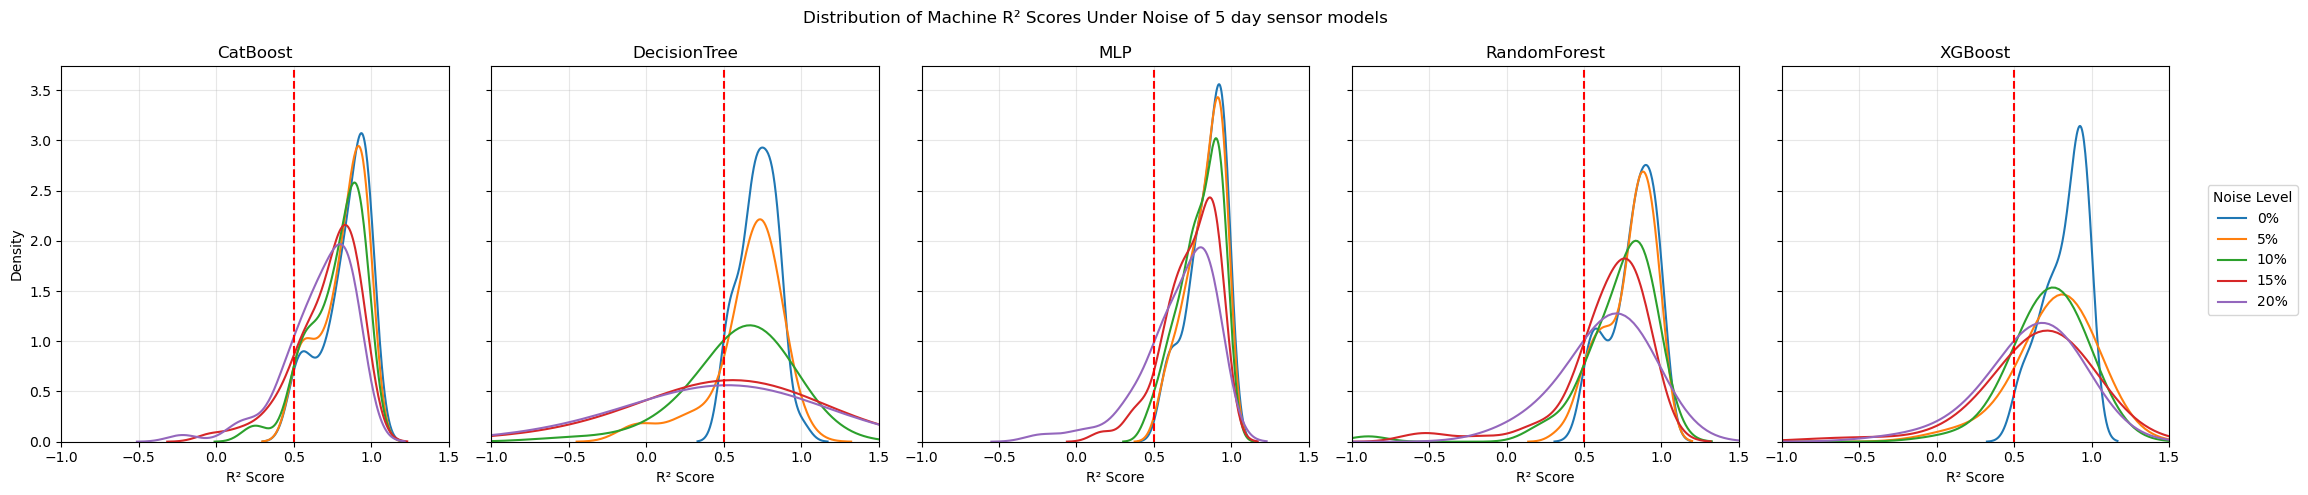

In [40]:

noise_cols = ["0%", "5%", "10%", "15%", "20%"]
models = per_machine_r2_5d["Model"].unique()

fig, axes = plt.subplots(1, len(models), figsize=(22,5), sharey=True)

for i, model in enumerate(models):

    model_df = per_machine_r2_5d[per_machine_r2_5d["Model"] == model]

    # keep machines with baseline R² > 0.5
    filtered_df = model_df[model_df["0%"] > 0.5]

    for noise in noise_cols:
        sns.kdeplot(
            filtered_df[noise],
            label=noise,
            ax=axes[i]
        )

    axes[i].axvline(0.5, linestyle="--", color="red")
    axes[i].set_title(model)
    axes[i].set_xlabel("R² Score")
    axes[i].set_xlim(-1, 1.5)
    axes[i].grid(alpha=0.3)

axes[0].set_ylabel("Density")

# ---- Single Legend Outside ----
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title="Noise Level",
    loc="center right",
    bbox_to_anchor=(1.05, 0.5)
)

# remove subplot legends
for ax in axes:
    ax.legend().remove()

plt.suptitle("Distribution of Machine R² Scores Under Noise of 5 day sensor models")
plt.tight_layout()
plt.savefig("Distribution_of_Machine_R²_Scores_Under_Noise_of_5_day_sensor_models.pdf", dpi=300, bbox_inches="tight")
plt.show()

# Explainer module

"Catboost SHAP summary plot"

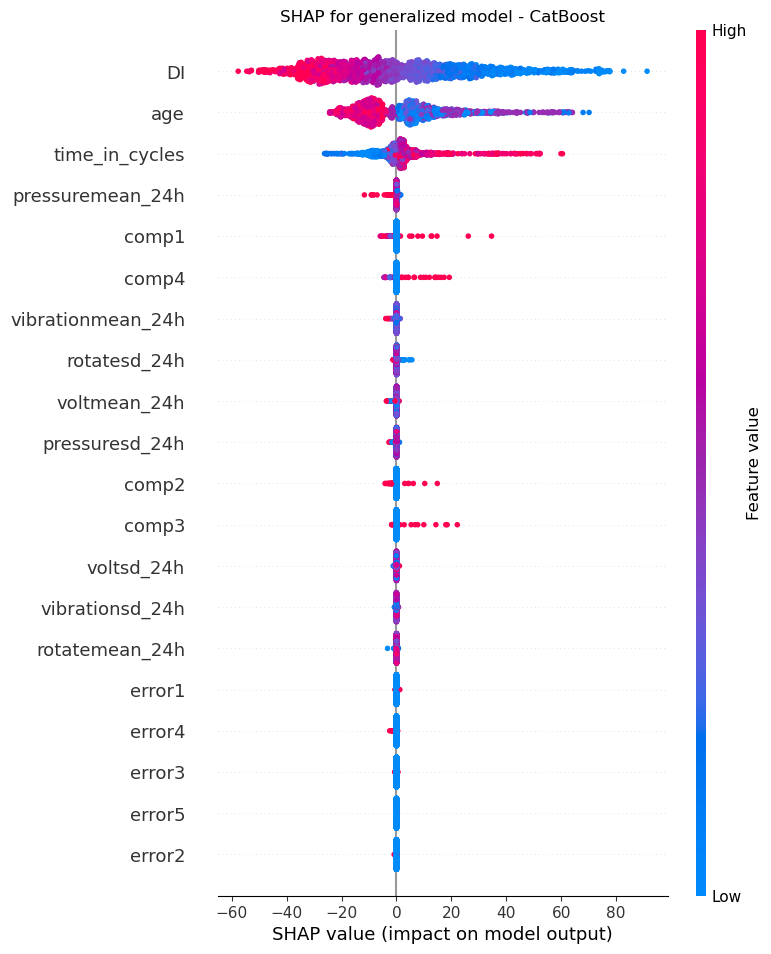

In [14]:
import shap
sample_data = test_24_general.sample(n=2000, random_state=42)

model = trained_models_24h['CatBoost']

explainer = shap.TreeExplainer(model)

# Compute SHAP values
shap_values = explainer.shap_values(sample_data)

# SHAP summary (beeswarm)
shap.summary_plot(
    shap_values,
    sample_data,
    show=False
)

plt.title("SHAP for generalized model - CatBoost")

# Save the plot
plt.savefig("shap_catboost_generalized.pdf", dpi=300, bbox_inches="tight")

plt.show()

"MLP SHAP summary plot"

100%|██████████████████████████████████████████████████████████████████████████████| 2000/2000 [02:59<00:00, 11.13it/s]


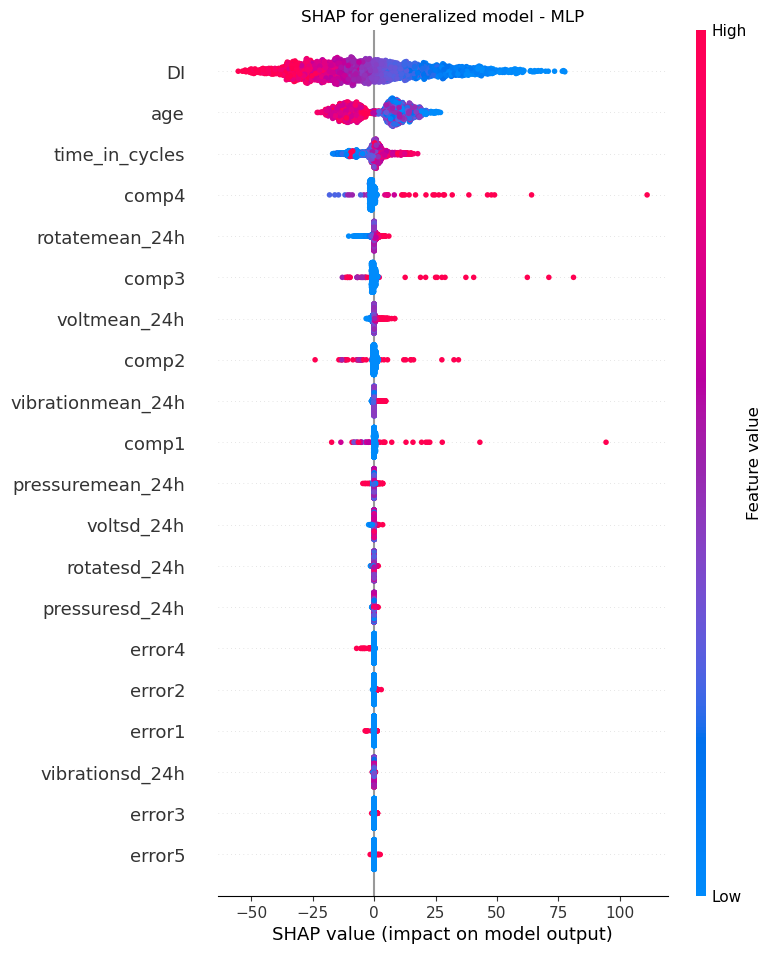

In [15]:

# Small samples (Kernel SHAP must be small)
background = test_24_general.sample(n=100, random_state=42)
sample_data = test_24_general.sample(n=2000, random_state=42)

model = trained_models_24h['MLP']

# Kernel SHAP for neural networks
explainer = shap.KernelExplainer(model.predict, background)

# Compute SHAP values
shap_values = explainer.shap_values(sample_data)

# Plot
shap.summary_plot(
    shap_values,
    sample_data,
    show=False
)

plt.title("SHAP for generalized model - MLP")

# Save
plt.savefig("shap_MLP_generalized.pdf", dpi=300, bbox_inches="tight")

plt.show()

"XGBoost SHAP summary plot"

PermutationExplainer explainer: 2001it [01:20, 23.25it/s]                                                              
C:\Users\ismai\AppData\Local\Temp\ipykernel_13628\260940587.py:13: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


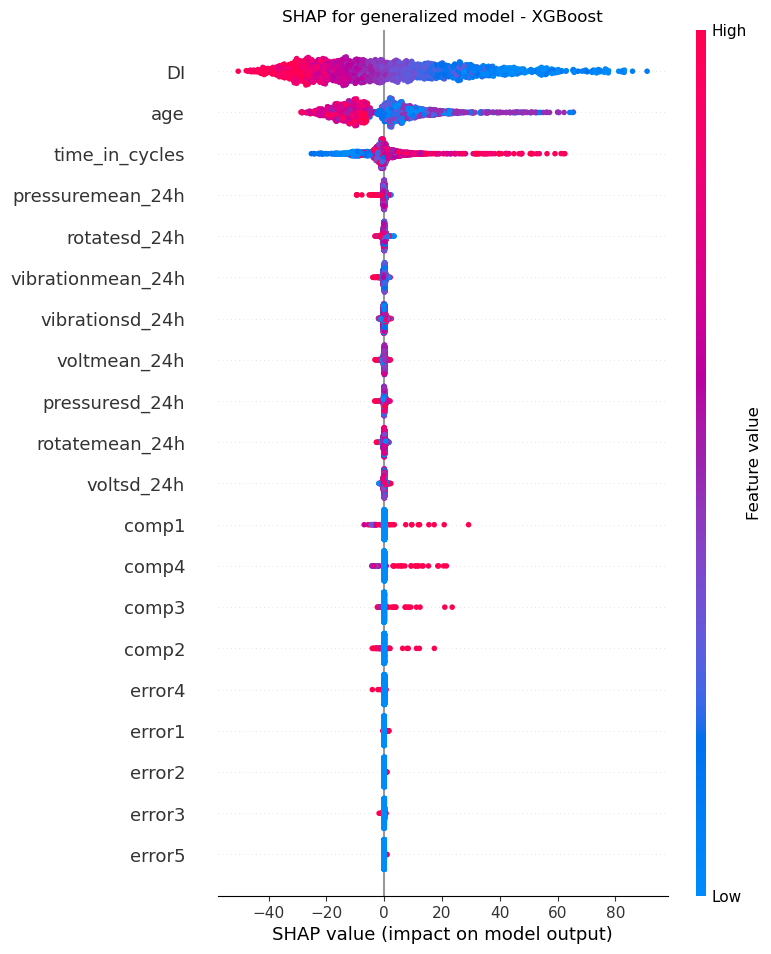

In [16]:


# Select 2000 samples
sample_data = test_24_general.sample(n=2000, random_state=42)

model = trained_models_24h['XGBoost']

# Use prediction function
explainer = shap.Explainer(model.predict, sample_data)

# Compute SHAP values
shap_values = explainer(sample_data)

# Plot
shap.summary_plot(
    shap_values,
    sample_data,
    show=False
)

plt.title("SHAP for generalized model - XGBoost")

plt.savefig("shap_xgboost_generalized.pdf", dpi=300, bbox_inches="tight")

plt.show()

"Random Forest SHAP summary plot"

C:\Users\ismai\AppData\Local\Temp\ipykernel_13628\62431551.py:12: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


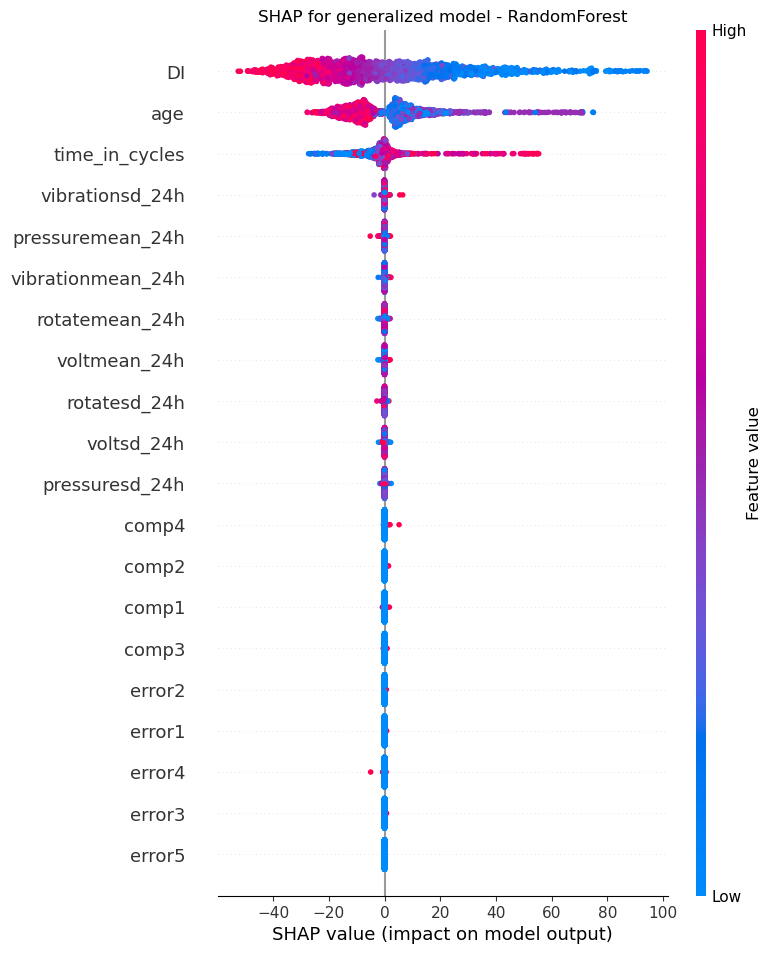

In [17]:

# Select 2000 samples from test data
sample_data = test_24_general.sample(n=2000, random_state=42)

model = trained_models_24h['RandomForest']

explainer = shap.TreeExplainer(model)

# Compute SHAP values on the sample
shap_values = explainer.shap_values(sample_data)

# Plot
shap.summary_plot(
    shap_values,
    sample_data,
    show=False
)

plt.title("SHAP for generalized model - RandomForest")

# Save the plot
plt.savefig("shap_randomforest_generalized.pdf", dpi=300, bbox_inches="tight")

plt.show()

"Decision tree SHAP summary plot"

C:\Users\ismai\AppData\Local\Temp\ipykernel_13628\1473097121.py:12: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


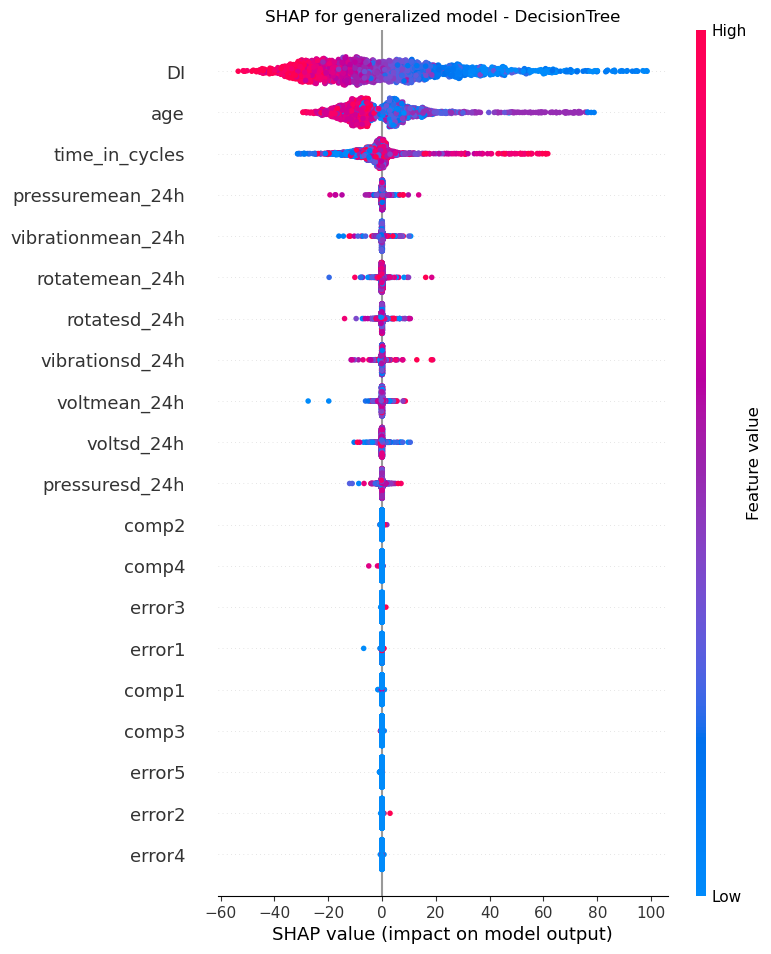

In [18]:


# Take a subset of 2000 samples
sample_data = test_24_general.sample(n=2000, random_state=42)

model = trained_models_24h['DecisionTree']

explainer = shap.TreeExplainer(model)

# Compute SHAP values
shap_values = explainer.shap_values(sample_data)

# Plot SHAP summary
shap.summary_plot(
    shap_values,
    sample_data,
    show=False
)

plt.title("SHAP for generalized model - DecisionTree")

# Save plot
plt.savefig("shap_decisiontree_generalized.pdf", dpi=300, bbox_inches="tight")

plt.show()